# Audio Deepfake Detection - Project Report

**A systematic comparison of deep-learning architectures for real-vs-fake speech detection, emphasising cross-dataset generalisation and per-class behaviour under class imbalance.**

Deep Learning course project. All models are **trained and validated on Fake-or-Real (FoR)** (in-domain) and **tested on In-the-Wild (ITW)** (cross-dataset), so every headline number measures generalisation to an unseen domain rather than in-distribution fit.

---

## Summary

| Finding | Evidence |
|---|---|
| **Representation learning drives generalisation.** Cross-dataset AUC rises monotonically as more of the pipeline is learned. | MLP 0.79 -> CNN/CRNN 0.86-0.87 -> WavLM probe 0.92 (ITW AUC) |
| **Accuracy & AUC hide the real weakness: catching fakes.** On the real-heavy ITW set, weak models reach decent accuracy while missing most spoofed clips. | Fake-class **recall**: MLP 0.17, RNN 0.17, CRNN 0.54, CNN 0.72 |
| **Convolution carries the recurrent path.** A pure BiLSTM is weak; a CNN front-end recovers nearly all the CNN performance. | RNN AUC 0.66 vs CRNN 0.86 |
| **Under domain shift, freezing the backbone beats fine-tuning.** | FoR AUC up to 0.99 while ITW AUC down to ~0.86; frozen probe ITW AUC 0.92 |
| **The spoofing cue is a mid-network acoustic feature.** | transformer-only probe puts ~81% weight on layer 3 (13-layer CNN-incl variant agrees) |

---

## 1. Objective

Binary classification of speech as **real (bonafide)** vs **fake (spoofed / synthetic)**. Instead of fine-tuning one pretrained model, the project asks *which inductive biases actually help*, by comparing four families that differ in how much of the pipeline is learned from data:

| # | Family | Input representation | What it tests |
|---|--------|----------------------|---------------|
| 1 | **MLP** | hand-crafted features (MFCC, chroma, spectral contrast, ZCR) | classical features + shallow classifier |
| 2 | **CNN** | mel-spectrogram | learned 2-D spectral features |
| 3 | **RNN / CRNN** | mel-spectrogram as a time series | temporal modelling (BiLSTM), with / without a CNN front-end |
| 4 | **WavLM** | raw waveform | self-supervised transformer (`microsoft/wavlm-base-plus`) - frozen probe vs full fine-tune |

Families 1-3 get focused **one-axis ablations** (capacity, learning rate, regularisation). Family 4 is an analysis of *how* to use a pretrained backbone. The research contribution is the **comparative analysis**, not the use of any one model.


## 2. Datasets & evaluation protocol

| Split | Dataset | Role |
|-------|---------|------|
| Train + Validation | **Fake-or-Real (FoR)**, `for-norm` | in-domain fitting & model selection |
| Test | **In-the-Wild (ITW)**, trimmed + normalised | **cross-dataset** generalisation |

**Cross-dataset by design.** Testing on a split of the *training* corpus overstates anti-spoofing performance because models latch onto corpus-specific artefacts. Training on FoR and testing on the independently collected ITW set (**31,779 clips - 19,963 real / 11,816 fake**) gives an honest estimate, and the FoR->ITW gap is itself a key diagnostic.

**Class imbalance.** ITW is **~63% real / 37% fake**. A model that simply leans "real" can post a deceptively high accuracy while failing at the actual job (flagging fakes). We therefore report **per-class precision/recall/F1**, and treat **fake-class recall** - the fraction of spoofed clips actually caught - as the operationally important number alongside AUC.

**Preprocessing.** 16 kHz mono; fixed-duration center-crop/pad. Feature scalers are **fit on the clean training split only** and reused unchanged at test time (no leakage). Train-time noise augmentation (Section 7) is applied to the **training split only**.

**Metrics.** AUC-ROC (threshold-free, primary), accuracy, per-class precision/recall/F1. EER is the conventional anti-spoofing headline; per-sample scores were not retained, so EER is a follow-up (Section 10).


## 3. Setup
The cells below load the **committed** experiment results under `results/` - this notebook presents them, it does not retrain. Run from the repository root.

In [1]:
import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")

# --- shared visual style -------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#22303a",
    "axes.edgecolor": "#9aa7b0",
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#c9d3da",
    "grid.alpha": 0.5,
    "grid.linewidth": 0.7,
    "xtick.color": "#42505a",
    "ytick.color": "#42505a",
    "text.color": "#22303a",
})
# cohesive palette (teal / blue / amber / coral / violet / slate)
PAL = {"teal": "#0E9594", "blue": "#3E7CB1", "amber": "#E9B949",
       "coral": "#E8674F", "violet": "#8E7CC3", "slate": "#5C6B73",
       "ink": "#22303a", "mute": "#cfd8dd"}

ROOT = Path.cwd()
RESULTS = ROOT / "results"

def load_summary(rel):
    return pd.read_csv(RESULTS / rel).sort_values("auc", ascending=False).reset_index(drop=True)

FAM = {"MLP": "nn_experiments/simple_nn", "CNN": "cnn_experiments/cnn",
       "CRNN": "crnn_experiments/crnn", "RNN": "rnn_experiments/rnn"}
summ = {k: load_summary(f"{v}/comparison/metrics_summary.csv") for k, v in FAM.items()}
print("Runs per family:", {k: len(v) for k, v in summ.items()})

def _parse_clf(p):
    t = Path(p).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def family_metrics(fam, sub):
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        Rf, (Fp, Fr, Ff) = rep["Real"][2], rep["Fake"]
        rows.append({"tag": tag, "AUC": r["auc"], "accuracy": r["test_acc"],
                     "macro_F1": (Rf + Ff) / 2, "fake_recall": Fr})
    return pd.DataFrame(rows)

_ABBR = {"depth": "depth", "base_channels": "ch", "lr": "lr", "dropout": "do",
         "weight_decay": "wd", "cnn_depth": "cd", "num_rnn_layers": "rl",
         "rnn_hidden": "rh", "num_layers": "L", "hidden_size": "h", "hidden_sizes": "h"}

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)):
        return f"{v:.0e}".replace("e-0", "e-").replace("e+0", "e") if (v != 0 and abs(v) < 1e-2) else f"{v:g}"
    return str(v)

def plot_family(fam, sub):
    # labels built from the ACTUAL hyperparameter values (same as the table), not the tag
    d = family_table(fam, sub).iloc[::-1].reset_index(drop=True)   # ascending AUC for barh
    cols = CONFIG_COLS[fam]
    labels = [", ".join(f"{_ABBR.get(c, c)}={_fmt(r[c])}" for c in cols) for _, r in d.iterrows()]
    y = np.arange(len(d)); h = 0.2
    mets = [("AUC", "AUC", PAL["teal"]), ("accuracy", "accuracy", PAL["blue"]),
            ("macro_F1", "macro-F1", PAL["amber"]), ("fake_R", "fake recall", PAL["coral"])]
    plt.figure(figsize=(10, 0.6 * len(d) + 1.8))
    for i, (col, lab, c) in enumerate(mets):
        off = (1.5 - i) * h
        plt.barh(y + off, d[col], h, label=lab, color=c, edgecolor="white", linewidth=0.4)
    plt.yticks(y, labels, fontsize=7.5); plt.xlim(0, 1.0); plt.xlabel("score")
    plt.title(f"{fam}: performance metrics across configurations")
    plt.legend(loc="lower right", ncol=2, fontsize=8, framealpha=0.9)
    plt.tight_layout(); plt.show()

CONFIG_COLS = {
    "MLP":  ["hidden_sizes", "lr", "dropout", "weight_decay"],
    "CNN":  ["depth", "base_channels", "lr", "dropout", "weight_decay"],
    "CRNN": ["cnn_depth", "base_channels", "num_rnn_layers", "rnn_hidden", "lr", "dropout", "weight_decay"],
    "RNN":  ["num_layers", "hidden_size", "lr", "dropout", "weight_decay"],
}

def family_table(fam, sub):
    # per-configuration table: actual hyperparameter values + saved per-class metrics
    rows = []
    for _, r in summ[fam].iterrows():
        tag = r["tag"]
        rep = _parse_clf(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
        (Rp, Rr, Rf), (Fp, Fr, Ff) = rep["Real"], rep["Fake"]
        row = {c: r[c] for c in CONFIG_COLS[fam]}
        row.update({"AUC": r["auc"], "accuracy": r["test_acc"], "macro_F1": (Rf + Ff) / 2,
                    "real_P": Rp, "real_R": Rr, "real_F1": Rf,
                    "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff})
        rows.append(row)
    return pd.DataFrame(rows).sort_values("AUC", ascending=False).reset_index(drop=True)

def _sortkey(v):
    try:
        return (0, float(v), 0)
    except (TypeError, ValueError):
        nums = [int(x) for x in re.findall(r"\d+", str(v))]
        return (1, len(nums), nums[0] if nums else 0)

def plot_hparam_effects(fam, sub, metrics=("AUC", "accuracy", "macro_F1")):
    # controlled one-axis view: vary ONE hyperparameter, hold the others at the baseline
    import math
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    d = family_table(fam, sub)
    cols = CONFIG_COLS[fam]
    base = {c: d[c].mode().iloc[0] for c in cols}          # baseline = most common value per axis
    mc = {"AUC": PAL["teal"], "accuracy": PAL["blue"], "macro_F1": PAL["amber"], "fake_R": PAL["coral"]}
    specs = []
    
    for h in cols:
        others = [c for c in cols if c != h]
        if others:
            mask = (d[others] == pd.Series({c: base[c] for c in others})).all(axis=1)
            sd = d[mask]
        else:
            sd = d
        if sd[h].nunique() >= 2:
            specs.append((h, sd))
            
    n = len(specs); ncol = min(3, n); nrow = math.ceil(n / ncol)
    fig, axs = plt.subplots(nrow, ncol, figsize=(4.3 * ncol, 3.2 * nrow), squeeze=False)
    
    for ax in axs.flat:
        ax.set_visible(False)
        
    for k, (h, sd) in enumerate(specs):
        ax = axs[k // ncol][k % ncol]; ax.set_visible(True)
        sd = sd.assign(_sk=sd[h].map(_sortkey)).sort_values("_sk")
        xpos = np.arange(len(sd)); xlab = [_fmt(v) for v in sd[h]]
        
        for met in metrics:
            ax.plot(xpos, sd[met], marker="o", ms=5, lw=2, color=mc.get(met), label=met.replace("_", "-"))
            
        bi = [i for i, v in enumerate(sd[h]) if _fmt(v) == _fmt(base[h])]
        if bi:
            ax.axvline(bi[0], color=PAL["slate"], ls=":", lw=1.1, alpha=0.75)
            ax.text(bi[0], 0.47, "baseline", rotation=90, fontsize=7, color=PAL["slate"], va="bottom", ha="right")
            
        # Tilted x-axis labels
        ax.set_xticks(xpos)
        ax.set_xticklabels(xlab, fontsize=8, rotation=45, ha="right")
        
        ax.set_title(_ABBR.get(h, h), fontsize=10, fontweight="bold")
        ax.set_ylim(0.45, 1.0); ax.grid(alpha=0.3); ax.set_xlabel(h, fontsize=8)

    # --- MODIFICATION: Move legend ABOVE the plots ---
    handles, labels = ax.get_legend_handles_labels()
    
    # loc="upper center" and bbox_to_anchor center it. 
    # ncol=len(labels) forces the legend to be a single horizontal row.
    fig.legend(handles, labels, fontsize=9, loc="upper center", 
               bbox_to_anchor=(0.5, 0.94), ncol=len(labels))

    # Placed the title slightly higher so it sits above the new legend
    fig.suptitle(f"{fam}: effect of each hyperparameter (others held at baseline)", 
                 fontweight="bold", y=0.98)
    
    # The 'rect' argument [left, bottom, right, top] restricts the subplots 
    # to the bottom 88% of the figure, leaving the top 12% empty for the title and legend.
    fig.tight_layout(rect=[0, 0, 1, 0.88]) 
    
    plt.show()

Runs per family: {'MLP': 10, 'CNN': 10, 'CRNN': 10, 'RNN': 10}


## 4. Architecture 1 - MLP on hand-crafted features
A shallow fully-connected network over classical descriptors (MFCC, chroma, spectral contrast, ZCR) aggregated per clip. No representation learning - the baseline.

**Ablation:** hidden width / depth, learning rate, dropout, weight decay.

In [2]:
family_table("MLP", "nn_experiments/simple_nn")

,hidden_sizes,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,"[256, 128, 64]",0.0010,0.5000,0.0001,0.7864,0.6832,0.5436,0.6667,0.9873,0.7960,0.8914,0.1740,0.2912
1,"[256, 128, 64]",0.0005,0.5000,0.0001,0.7694,0.6629,0.4989,0.6527,0.9865,0.7856,0.8433,0.1214,0.2122
2,[128],0.0005,0.5000,0.0001,0.7600,0.6630,0.4948,0.6519,0.9904,0.7863,0.8771,0.1150,0.2033
3,"[256, 128, 64, 32]",0.0005,0.5000,0.0001,0.7588,0.6687,0.5147,0.6572,0.9841,0.7881,0.8414,0.1409,0.2413
4,"[256, 128]",0.0005,0.5000,0.0001,0.7493,0.6688,0.5126,0.6568,0.9863,0.7885,0.8571,0.1373,0.2367
5,"[256, 128, 64]",0.0005,0.5000,0.0010,0.7488,0.6725,0.5231,0.6598,0.9842,0.7900,0.8506,0.1507,0.2561
6,"[512, 256, 128, 64]",0.0005,0.5000,0.0001,0.7416,0.6636,0.4986,0.6528,0.9883,0.7863,0.8599,0.1203,0.2110
7,"[256, 128, 64]",0.0005,0.3000,0.0001,0.7316,0.6667,0.5086,0.6555,0.9855,0.7873,0.8454,0.1331,0.2299
8,"[256, 128, 64]",0.0001,0.5000,0.0001,0.7304,0.6520,0.4781,0.6461,0.9817,0.7793,0.7657,0.1001,0.1770
9,"[512, 256, 128]",0.0005,0.5000,0.0001,0.6941,0.6587,0.4908,0.6501,0.9847,0.7832,0.8152,0.1130,0.1984


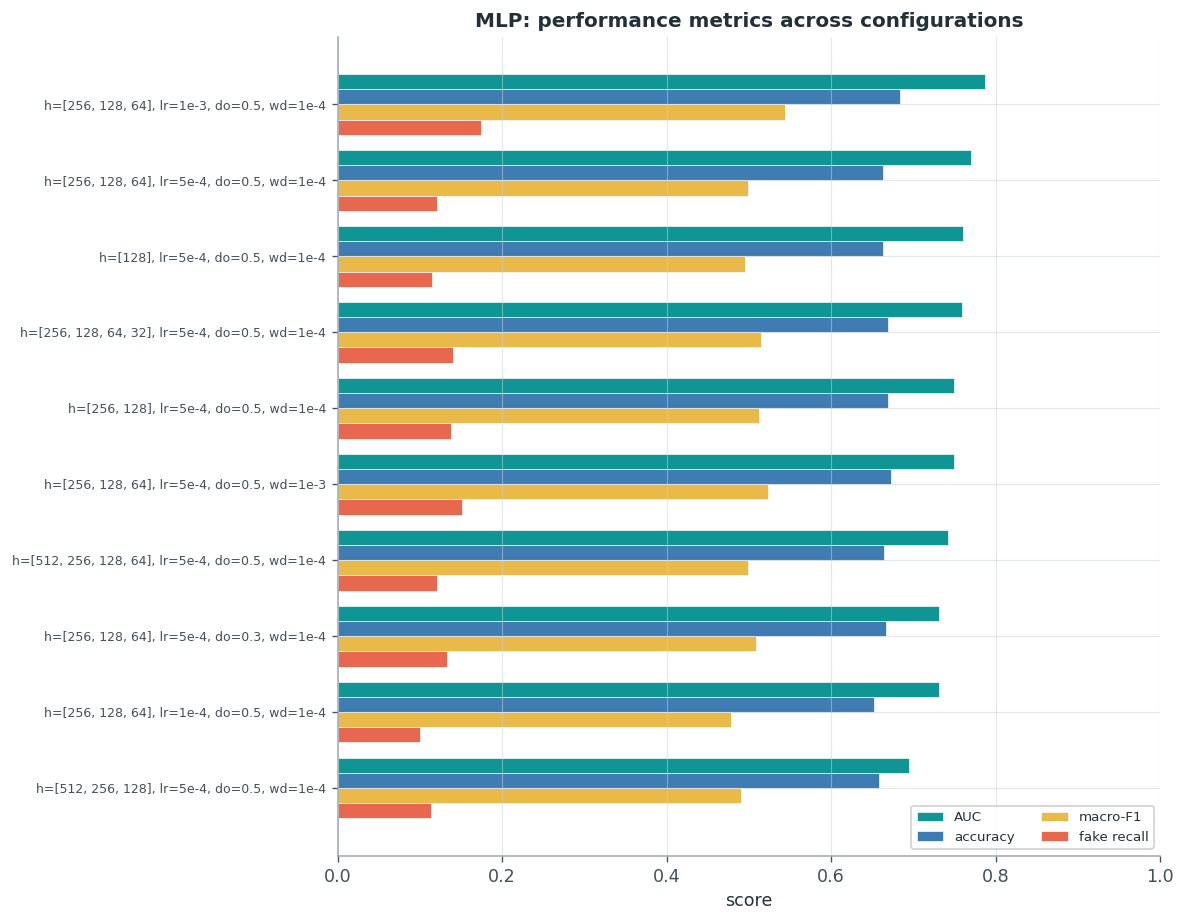

In [3]:
plot_family("MLP", "nn_experiments/simple_nn")

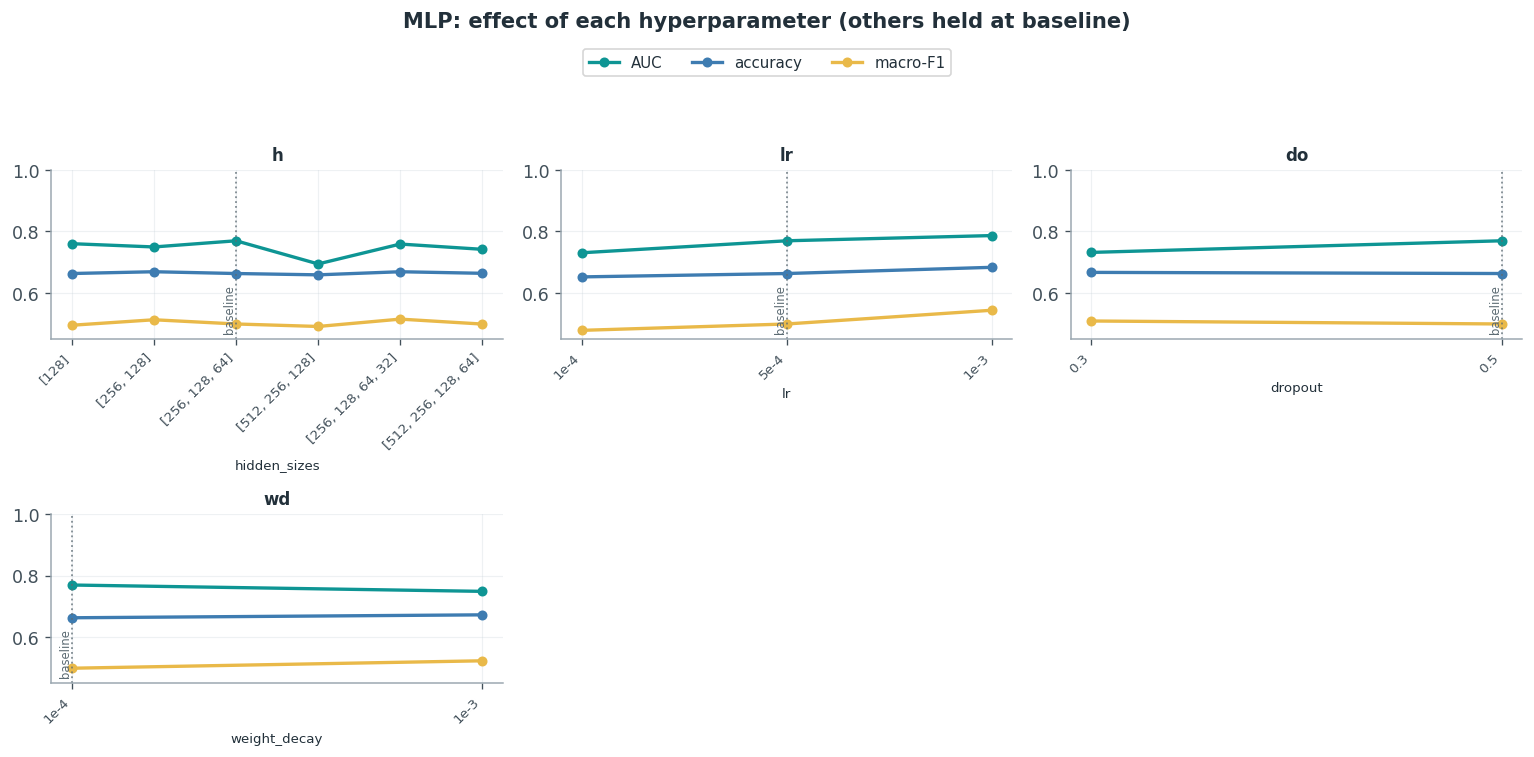

In [4]:
plot_hparam_effects("MLP", "nn_experiments/simple_nn")

**Interpretation.** Caps at **AUC ~ 0.79 / acc ~ 0.68** - above chance but the weakest learned model.

- **Capacity does not help.** The widest nets (`512-256-128(-64)`) do *worse*: they overfit FoR-specific structure and transfer less well. Best is a modest `256-128-64`.
- **Learning rate dominates.** `1e-3` clearly beats `5e-4`/`1e-4` - the low-dimensional feature space has a benign loss surface where a larger step finds a better basin within the epoch budget.

The ceiling is set by the **features**, not the classifier: hand-crafted descriptors discard the fine spectro-temporal detail that exposes modern synthesis artefacts. (Section 8 shows this MLP also has near-zero fake recall - it mostly predicts real.)

## 5. Architecture 2 - CNN on mel-spectrograms
A 2-D CNN over the mel-spectrogram, learning local spectro-temporal filters end-to-end.

**Ablation:** conv depth, base channels, learning rate, dropout, weight decay.

In [5]:
family_table("CNN", "cnn_experiments/cnn")

,depth,base_channels,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,0.0010,0.5000,0.0001,0.8702,0.8266,0.8103,0.8418,0.8914,0.8659,0.7963,0.7170,0.7546
1,3,64,0.0005,0.5000,0.0001,0.8640,0.8146,0.7856,0.7994,0.9408,0.8644,0.8575,0.6012,0.7068
2,4,32,0.0005,0.5000,0.0001,0.8377,0.7778,0.7364,0.7641,0.9350,0.8410,0.8234,0.5124,0.6317
3,3,32,0.0005,0.3000,0.0001,0.7712,0.7411,0.6885,0.7359,0.9169,0.8165,0.7599,0.4441,0.5605
4,3,16,0.0005,0.5000,0.0001,0.7091,0.6605,0.6469,0.7543,0.6817,0.7161,0.5374,0.6248,0.5778
5,3,32,0.0005,0.5000,0.0001,0.6814,0.6703,0.6302,0.7129,0.7956,0.7520,0.5705,0.4586,0.5085
6,3,32,0.0005,0.5000,0.0000,0.6705,0.6556,0.6247,0.7153,0.7505,0.7325,0.5402,0.4953,0.5168
7,3,32,0.0005,0.5000,0.0010,0.5644,0.5252,0.5223,0.6707,0.4796,0.5593,0.4065,0.6021,0.4853
8,2,32,0.0005,0.5000,0.0001,0.5484,0.5288,0.5216,0.6588,0.5184,0.5802,0.4017,0.5464,0.4630
9,3,32,0.0001,0.5000,0.0001,0.5479,0.5198,0.5154,0.6588,0.4886,0.5610,0.3985,0.5725,0.4699


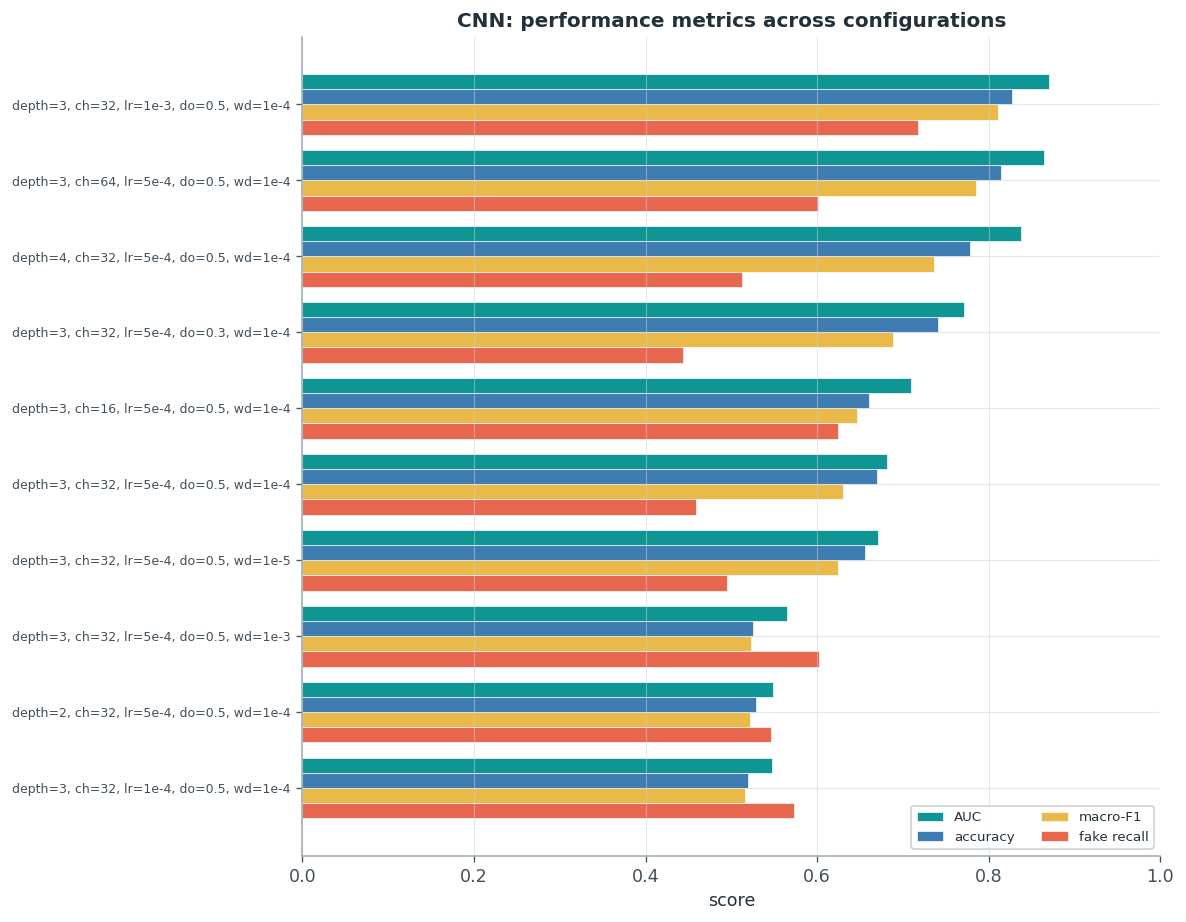

In [6]:
plot_family("CNN", "cnn_experiments/cnn")

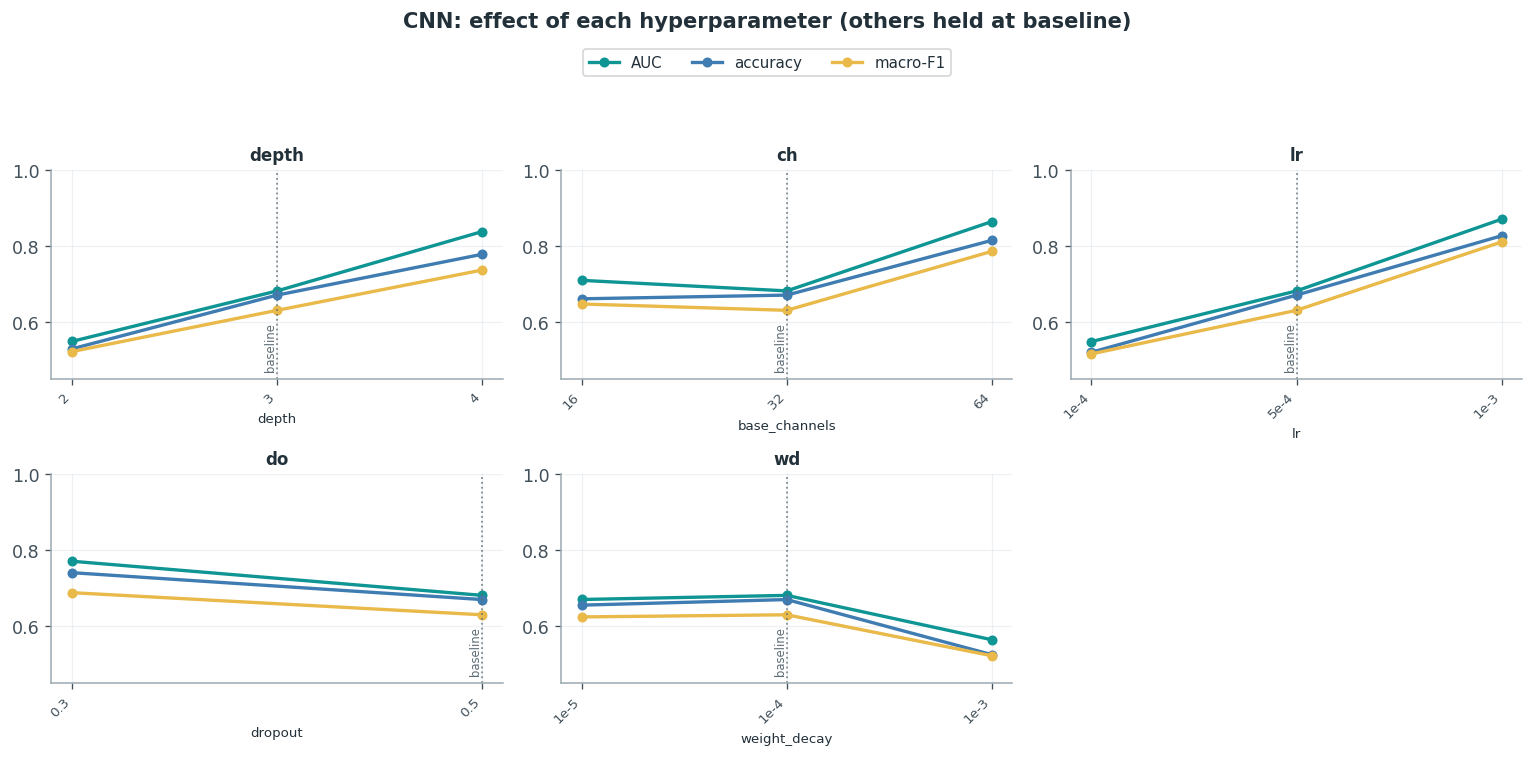

In [7]:
plot_hparam_effects("CNN", "cnn_experiments/cnn")

**Interpretation.** The **strongest non-pretrained model: AUC ~ 0.87 / acc ~ 0.83**, and the best fake-recall of any model here.

- **Depth has a sweet spot.** 3 conv blocks is best; 4 hurts, 2 collapses (AUC 0.55).
- **Enough width is necessary, more is not free.** 16 channels underperforms, 32 is the sweet spot, 64 adds nothing.
- **Regularisation is delicate.** Weight decay `1e-3` is catastrophic (AUC 0.56); `1e-4` is right. Dropout 0.5 > 0.3.
- Best: **`depth 3, ch 32, lr 1e-3, dropout 0.5, wd 1e-4`**.

## 6. Architecture 3 - Recurrent models (RNN & CRNN)
Two temporal variants on the same mel input: a pure **BiLSTM (RNN)** over frame vectors, and a **CRNN** with a CNN front-end before the BiLSTM.

**Ablation:** recurrent layers, hidden size, (CRNN) conv depth/channels, learning rate, dropout.

In [8]:
print("=== CRNN ==="); display(family_table("CRNN", "crnn_experiments/crnn"))
print("\n=== RNN (pure BiLSTM) ==="); display(family_table("RNN", "rnn_experiments/rnn"))

=== CRNN ===


,cnn_depth,base_channels,num_rnn_layers,rnn_hidden,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,3,32,2,128,0.0005,0.5000,0.0001,0.8596,0.8054,0.7667,0.7783,0.9651,0.8617,0.9008,0.5355,0.6717
1,4,32,2,128,0.0005,0.5000,0.0001,0.8388,0.7899,0.7688,0.8101,0.8693,0.8387,0.7481,0.6558,0.6989
2,3,32,3,128,0.0005,0.5000,0.0001,0.8313,0.7541,0.7074,0.7478,0.9184,0.8244,0.7757,0.4766,0.5904
3,3,32,2,128,0.0005,0.3000,0.0001,0.7549,0.7354,0.6940,0.7457,0.8784,0.8066,0.7062,0.4939,0.5813
4,3,16,2,128,0.0005,0.5000,0.0001,0.7444,0.6791,0.5531,0.6702,0.9632,0.7904,0.7622,0.1991,0.3157
5,3,64,2,128,0.0005,0.5000,0.0001,0.7328,0.7313,0.6970,0.7538,0.8499,0.7990,0.6768,0.5309,0.5950
6,3,32,1,128,0.0005,0.5000,0.0001,0.7203,0.7220,0.6898,0.7523,0.8310,0.7897,0.6532,0.5378,0.5899
7,2,32,2,128,0.0005,0.5000,0.0001,0.6045,0.6264,0.5856,0.6857,0.7484,0.7157,0.4972,0.4203,0.4555
8,3,32,2,128,0.0010,0.5000,0.0001,0.5565,0.5269,0.5200,0.6575,0.5153,0.5778,0.4003,0.5465,0.4621
9,3,32,2,128,0.0001,0.5000,0.0001,0.5488,0.5694,0.5413,0.6595,0.6504,0.6549,0.4227,0.4325,0.4276



=== RNN (pure BiLSTM) ===


,num_layers,hidden_size,lr,dropout,weight_decay,AUC,accuracy,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,1,128,0.0005,0.5000,0.0001,0.6596,0.6524,0.5191,0.6562,0.9384,0.7723,0.6194,0.1693,0.2659
1,2,128,0.0010,0.5000,0.0001,0.6496,0.6586,0.5534,0.6673,0.9105,0.7701,0.6064,0.2330,0.3366
2,2,128,0.0005,0.3000,0.0001,0.6332,0.6583,0.5426,0.6638,0.9244,0.7727,0.6204,0.2089,0.3125
3,3,128,0.0005,0.5000,0.0001,0.6239,0.6505,0.5159,0.6550,0.9375,0.7712,0.6106,0.1656,0.2606
4,2,128,0.0001,0.5000,0.0001,0.5926,0.6436,0.5624,0.6693,0.8552,0.7509,0.5391,0.2861,0.3739
5,2,128,0.0005,0.5000,0.0001,0.5919,0.6465,0.4902,0.6484,0.9552,0.7724,0.6225,0.1249,0.2081
6,2,64,0.0005,0.5000,0.0001,0.5802,0.6498,0.5069,0.6527,0.9456,0.7723,0.6200,0.1500,0.2415
7,2,256,0.0005,0.5000,0.0001,0.5714,0.6379,0.5222,0.6540,0.8994,0.7573,0.5357,0.1961,0.2871
8,2,128,0.0005,0.5000,0.0000,0.5682,0.6487,0.5168,0.6548,0.9323,0.7693,0.5971,0.1696,0.2642
9,2,128,0.0005,0.5000,0.0010,0.4873,0.4566,0.4563,0.6075,0.3811,0.4684,0.3584,0.5840,0.4442


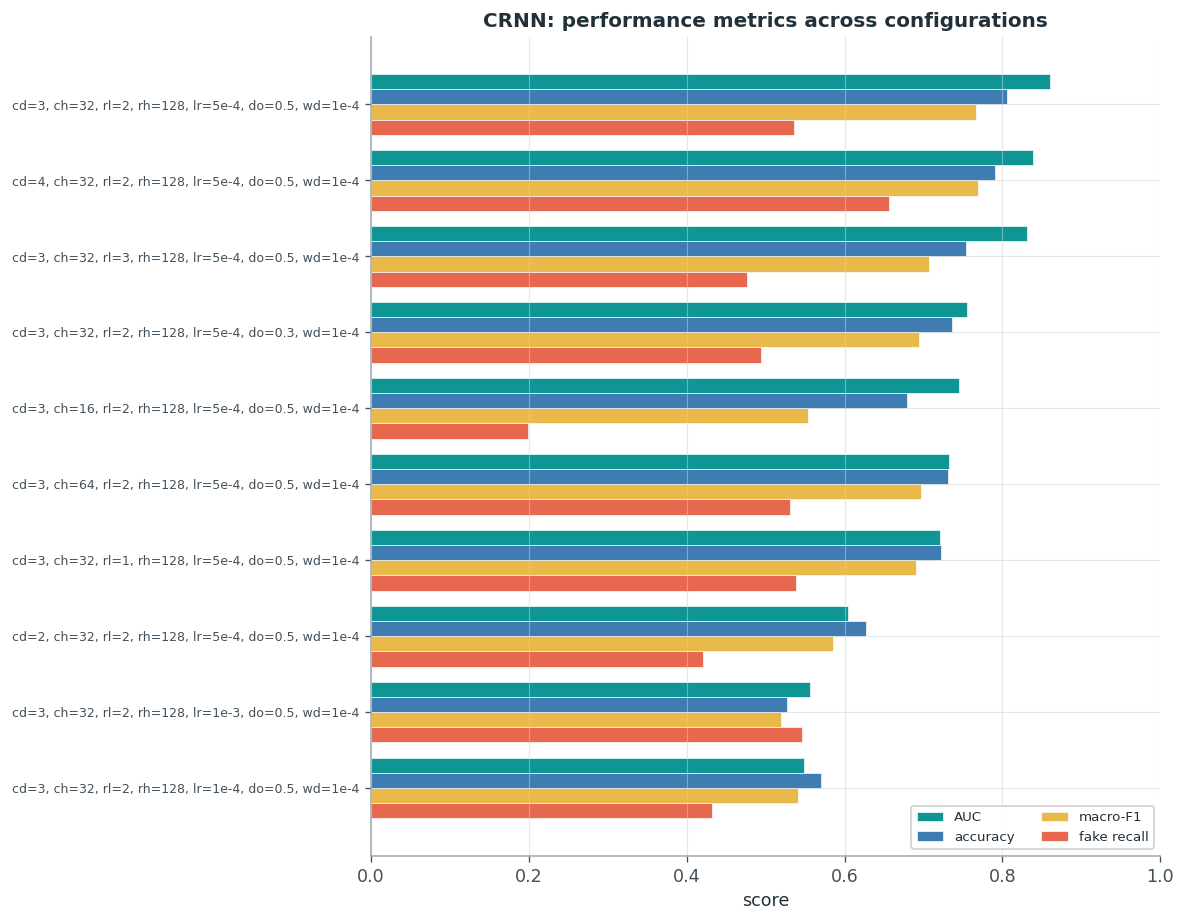

In [9]:
plot_family("CRNN", "crnn_experiments/crnn")

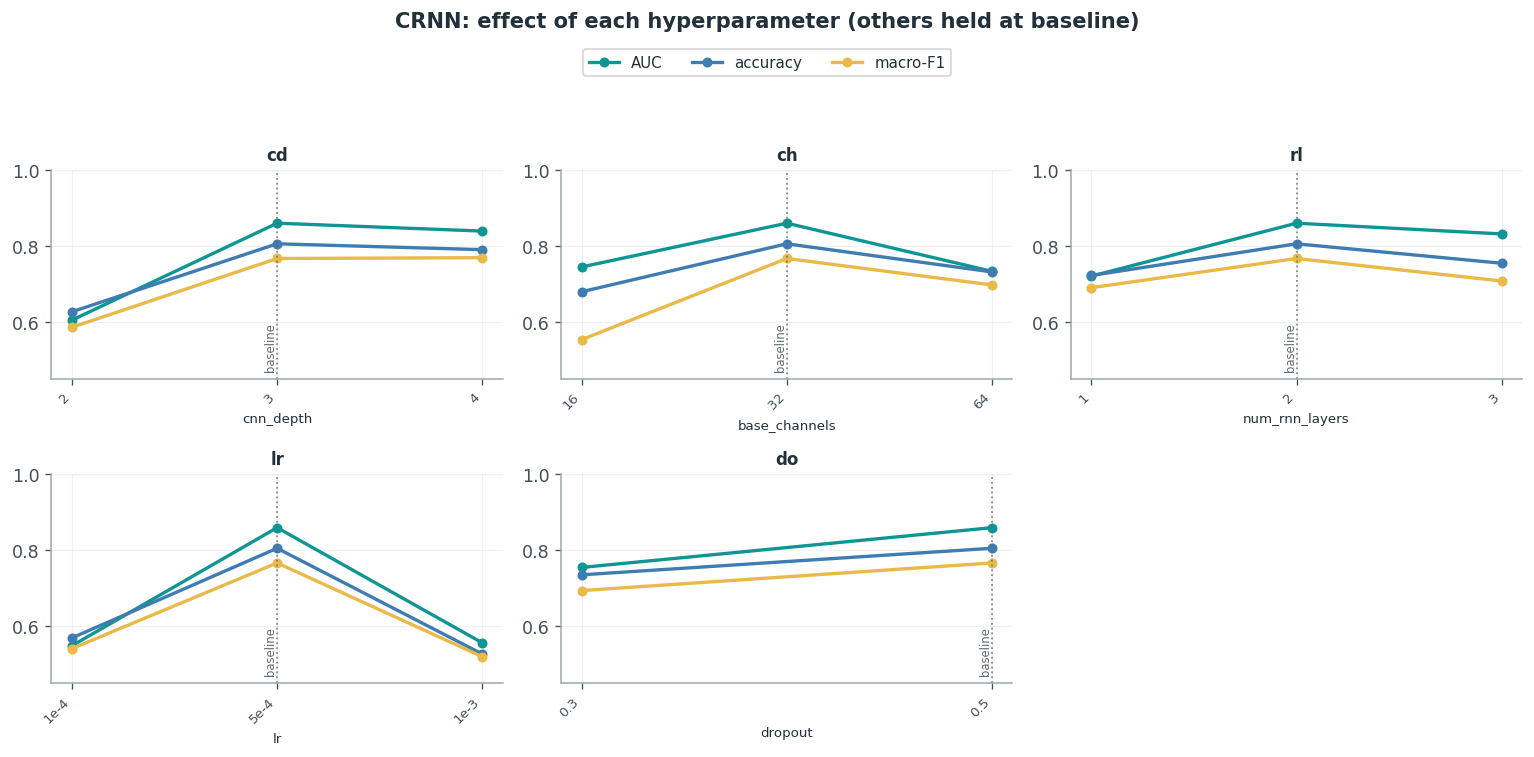

In [10]:
plot_hparam_effects("CRNN", "crnn_experiments/crnn")

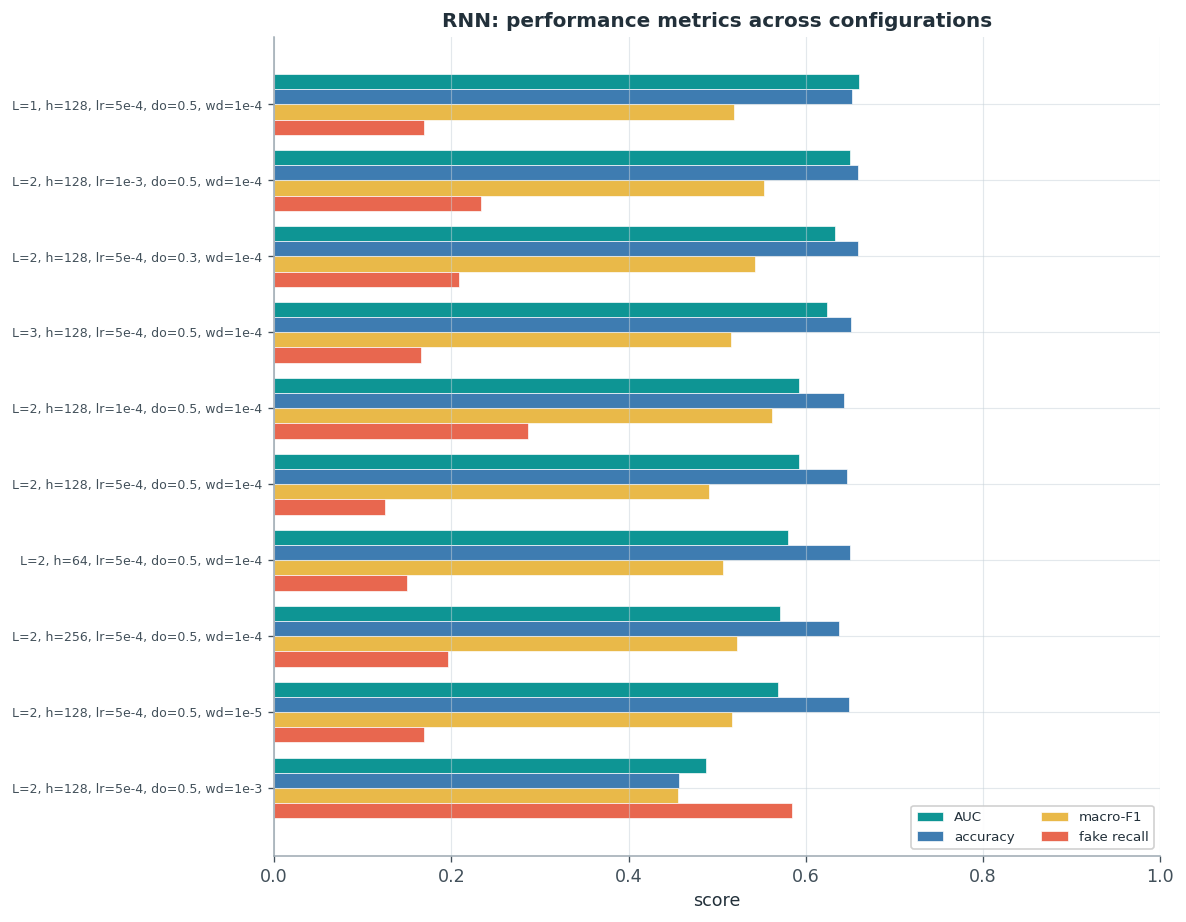

In [11]:
plot_family("RNN", "rnn_experiments/rnn")

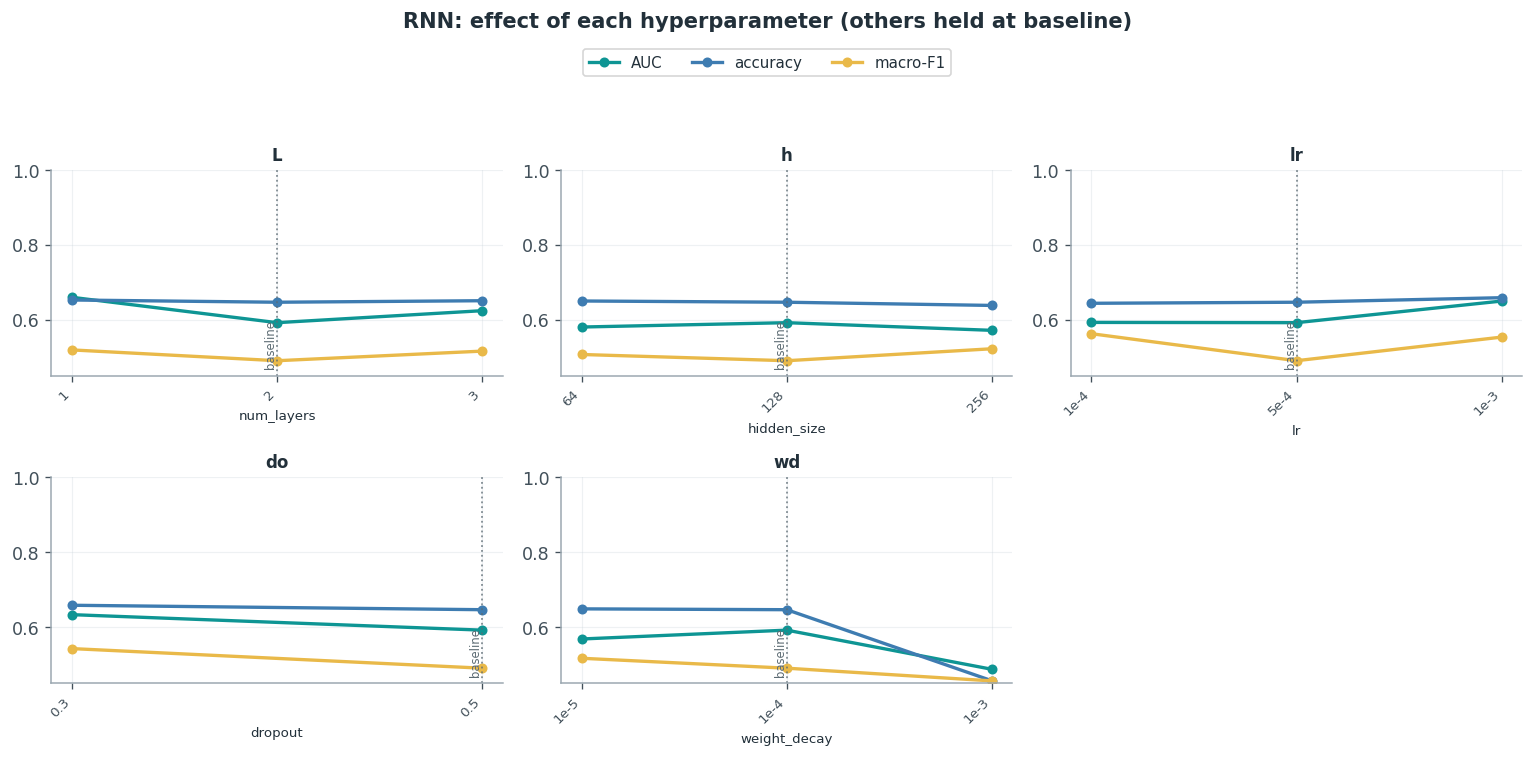

In [12]:
plot_hparam_effects("RNN", "rnn_experiments/rnn")

**Interpretation - the CNN front-end is what matters.**

- **CRNN reaches AUC ~ 0.86**, matching the pure CNN, while the **pure RNN tops out at 0.66**, barely above the MLP. Without a convolutional front-end the BiLSTM must learn both *what* the local patterns are and *how* they evolve, and does the first poorly.
- **CRNN** wins with the same recipe as the CNN; larger LR (`1e-3`) destabilises the recurrent path (AUC 0.56).
- **Pure RNN** gains nothing from more layers / wider hidden - bottlenecked by representation, not temporal capacity.

**Takeaway:** the discriminative work is **convolutional**; explicit temporal modelling adds little once a CNN front-end is present.

## 7. Architecture 4 - WavLM (self-supervised backbone)
`microsoft/wavlm-base-plus` consumes the **raw waveform**. Two usage modes:

- **Frozen probe** - backbone frozen; learn a softmax-weighted sum over its 13 hidden states + a linear head. Reveals *which layer encodes the spoofing cue*.
- **Full fine-tune** - entire backbone trainable (low LR) with online train-time augmentation (MUSAN noise / RIR reverb / codec). The **best** such variant is reported below.

In [13]:
_pf = sorted((RESULTS / "wavlm_base_plus").glob("metrics_probe_*.json"))
_primary = [p for p in _pf if "cnn_included" not in p.name] or _pf
probe = json.load(open(_primary[-1]))                       # transformer-only weighted-sum probe (12 layers)
probe_13L = next((json.load(open(p)) for p in _pf if "cnn_included" in p.name), None)  # 13-layer (CNN-incl) ablation

ft = []
for p in (RESULTS / "wavlm_base_plus_finetune").glob("metrics_*.json"):
    d = json.load(open(p))
    if "itw_test" in d and "auc" in d["itw_test"]:
        ft.append((d["itw_test"]["auc"], p.name, d))
ft.sort(reverse=True)
best_ft_auc, best_ft_name, best_ft = ft[0]
print(f"Best fine-tune variant by ITW AUC: {best_ft_name}  (ITW AUC {best_ft_auc:.4f})")

def wl_row(name, d):
    v, t = d["for_val"], d["itw_test"]
    return {"variant": name, "FoR_AUC": v["auc"], "FoR_acc": v["acc"],
            "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "ITW_fake_recall": t["recall_fake"], "ITW_fake_F1": t["f1_fake"]}

wavlm_df = pd.DataFrame([wl_row("frozen probe (weighted-sum)", probe),
                         wl_row("full fine-tune (best)", best_ft)])
wavlm_df

Best fine-tune variant by ITW AUC: metrics_finetune_top2_b32_20260620_160154.json  (ITW AUC 0.8645)


,variant,FoR_AUC,FoR_acc,ITW_AUC,ITW_acc,ITW_fake_recall,ITW_fake_F1
0,frozen probe (weighted-sum),0.9826,0.9204,0.9177,0.8147,0.5737,0.6971
1,full fine-tune (best),0.9946,0.9543,0.8645,0.7474,0.4450,0.5671


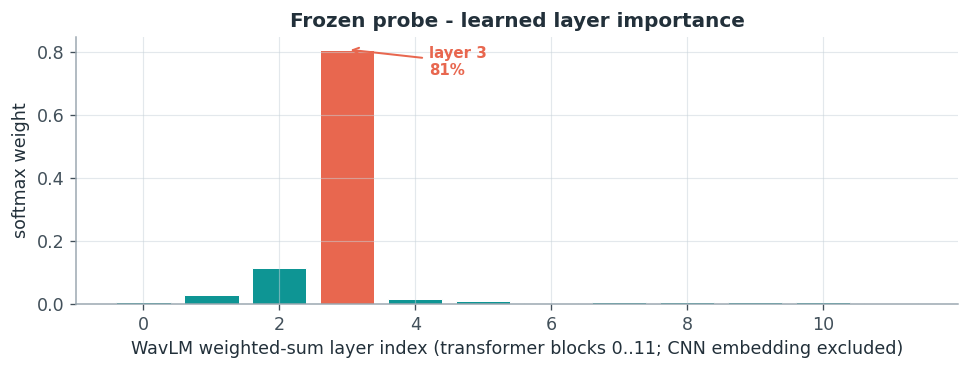

Dominant layer: 3 (weight 0.81)
13-layer (CNN-incl) ablation dominant layer: 4 (weight 0.85) - same transformer block


In [14]:
w = probe["layer_weights_softmax"]
dom = int(np.argmax(w))
colors = [PAL["coral"] if i == dom else PAL["teal"] for i in range(len(w))]
plt.figure(figsize=(8.2,3.2))
bars = plt.bar(range(len(w)), w, color=colors, edgecolor="white", linewidth=0.6)
plt.annotate(f"layer {dom}\n{w[dom]:.0%}", xy=(dom, w[dom]), xytext=(dom+1.2, w[dom]*0.9),
             color=PAL["coral"], fontweight="bold", fontsize=9,
             arrowprops=dict(arrowstyle="->", color=PAL["coral"], lw=1.2))
plt.xlabel("WavLM weighted-sum layer index" + (" (0 = CNN embeddings ... 12 = top)" if len(w) == 13 else " (transformer blocks 0..11; CNN embedding excluded)"))
plt.ylabel("softmax weight"); plt.title("Frozen probe - learned layer importance")
plt.tight_layout(); plt.show()
print("Dominant layer:", dom, f"(weight {max(w):.2f})")
if probe_13L:
    w13 = probe_13L["layer_weights_softmax"]
    print("13-layer (CNN-incl) ablation dominant layer:", int(np.argmax(w13)), f"(weight {max(w13):.2f}) - same transformer block")

**Interpretation - two key findings.**

**(a) The spoofing cue lives in an early-to-mid transformer block.** The (transformer-only) probe puts **~81% of its weight on layer 3** of 12, almost nothing on the top; the 13-layer ablation that also includes the CNN embedding independently concentrates on the *same* block (its layer 4), so the finding is robust to whether the CNN output is included. WavLM upper layers specialise toward the self-supervised phonetic/content objective; the **mid layers retain low-level acoustic detail** where synthesis artefacts (unnatural phase, spectral smoothing, vocoder fingerprints) are most visible. A naive last-layer head would have discarded the most useful signal.

**(b) Under domain shift, the frozen probe *beats* full fine-tuning.** The probe hits **ITW AUC 0.917** - the best cross-dataset result here - while the best fine-tune drives **FoR AUC to ~0.99** yet only reaches **ITW AUC 0.86**, with **fake recall collapsing to ~0.45**. Fine-tuning lets the backbone memorise FoR-specific artefacts at the cost of general features that transfer to ITW - a textbook **source-domain overfitting** trade-off. With a strong pretrained backbone and a test-time domain shift, **freezing can be the better choice.**

### 7.1 Embedding & score analysis

To see *why* the cross-dataset gap appears, the runs also saved **UMAP projections** of the pooled embeddings and **score histograms** (predicted fake-probability for true-real vs true-fake clips), for both the frozen probe and the best fine-tune.

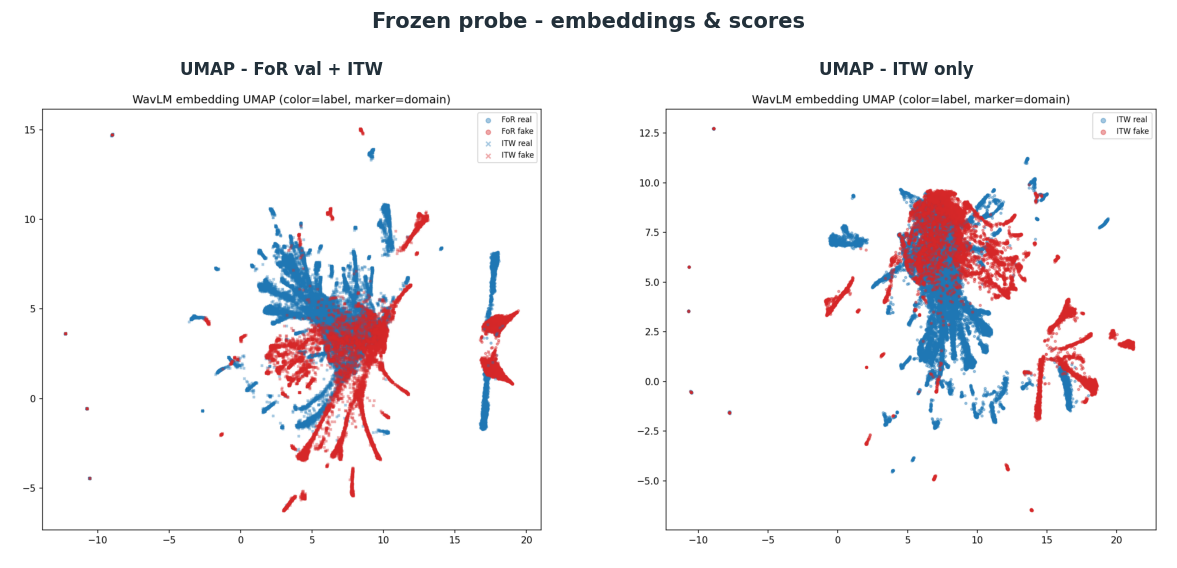

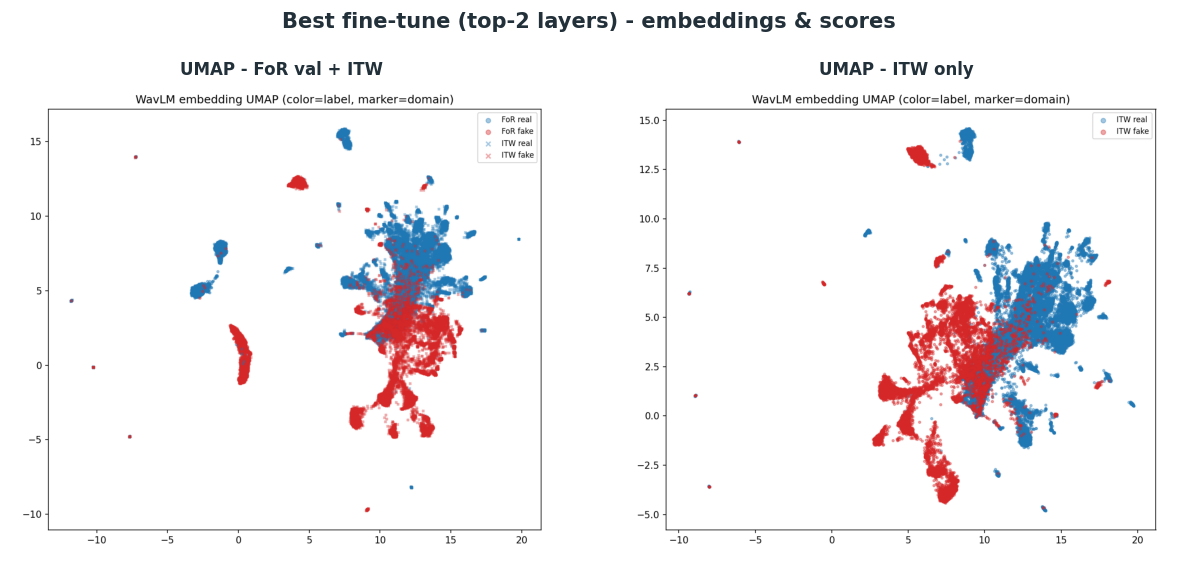

In [15]:
import matplotlib.image as mpimg
ANALYSIS = RESULTS / "wavlm_base_plus_analysis"

def _ititle(p):
    n = p.name
    if "umap_itw_only" in n: return "UMAP - ITW only"
    if "umap" in n:          return "UMAP - FoR val + ITW"
    if "scorehist" in n:     return "Score histogram"
    return n

def show_imgs(paths, suptitle):
    paths = list(paths)
    if not paths:
        print("(no images found)"); return
    fig, axs = plt.subplots(1, len(paths), figsize=(5.2*len(paths), 4.6), squeeze=False)
    for ax, p in zip(axs[0], paths):
        ax.imshow(mpimg.imread(p)); ax.axis("off"); ax.set_title(_ititle(p), fontsize=10)
    fig.suptitle(suptitle, fontweight="bold", y=1.02)
    fig.tight_layout(); plt.show()

probe_imgs = sorted(ANALYSIS.glob("probe_*.png"))
ft_imgs    = sorted(p for p in ANALYSIS.glob("*.png") if not p.name.startswith("probe_"))
show_imgs(probe_imgs, "Frozen probe - embeddings & scores")
show_imgs(ft_imgs,    "Best fine-tune (top-2 layers) - embeddings & scores")

**Reading the embeddings.** In the UMAP plots the FoR (in-domain) real/fake clusters separate cleanly, but the **ITW points spread across the boundary** - the visual signature of the domain shift that drags fake-recall down. The **score histograms** make the same point on the decision axis: real and fake are well separated on FoR, while on ITW the fake distribution leaks toward low scores (missed fakes), which is exactly why a threshold tuned in-domain under-detects ITW fakes.

## 8. Cross-architecture comparison
The most important section: best configuration per family **plus both WavLM modes**, with **full per-class metrics**. Feature-model per-class numbers are parsed from each run saved classification report.

In [16]:
def parse_clf_report(txt_path):
    t = Path(txt_path).read_text(); out = {}
    for cls in ("Real", "Fake"):
        m = re.search(cls + r"\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)", t)
        out[cls] = tuple(float(x) for x in m.groups()[:3])
    return out

def feat_row(fam, sub):
    top = summ[fam].iloc[0]; tag = top["tag"]
    rep = parse_clf_report(RESULTS / sub / "experiments" / tag / "checkpoints" / ("metrics_" + tag + ".txt"))
    Rp, Rr, Rf = rep["Real"]; Fp, Fr, Ff = rep["Fake"]
    return {"model": fam, "config/mode": tag, "ITW_AUC": top["auc"], "ITW_acc": top["test_acc"],
            "real_P": Rp, "real_R": Rr, "real_F1": Rf, "fake_P": Fp, "fake_R": Fr, "fake_F1": Ff, "macro_F1": (Rf+Ff)/2}

def wl_full(name, d):
    t = d["itw_test"]
    return {"model": name, "config/mode": "wavlm-base-plus", "ITW_AUC": t["auc"], "ITW_acc": t["acc"],
            "real_P": t["precision_real"], "real_R": t["recall_real"], "real_F1": t["f1_real"],
            "fake_P": t["precision_fake"], "fake_R": t["recall_fake"], "fake_F1": t["f1_fake"], "macro_F1": (t["f1_real"]+t["f1_fake"])/2}

rows = [feat_row(f, s) for f, s in FAM.items()]
rows.append(wl_full("WavLM (fine-tune, best)", best_ft))
rows.append(wl_full("WavLM (frozen probe)", probe))
master = pd.DataFrame(rows).sort_values("ITW_AUC", ascending=False).reset_index(drop=True)
master = master[["model","config/mode","ITW_AUC","ITW_acc","macro_F1","real_P","real_R","real_F1","fake_P","fake_R","fake_F1"]]
master

,model,config/mode,ITW_AUC,ITW_acc,macro_F1,real_P,real_R,real_F1,fake_P,fake_R,fake_F1
0,WavLM (frozen probe),wavlm-base-plus,0.9177,0.8147,0.7818,0.7914,0.9573,0.8665,0.8882,0.5737,0.6971
1,CNN,CNN_d3_ch32_lr1e-3_do0.5_wd1e-4,0.8702,0.8266,0.8103,0.8418,0.8914,0.8659,0.7963,0.7170,0.7546
2,"WavLM (fine-tune, best)",wavlm-base-plus,0.8645,0.7474,0.6944,0.7382,0.9264,0.8217,0.7816,0.4450,0.5671
3,CRNN,CRNN_cd3_ch32_rl2_rh128_lr5e-4_do0.5_wd1e-4,0.8596,0.8054,0.7667,0.7783,0.9651,0.8617,0.9008,0.5355,0.6717
4,MLP,NN_h256-128-64_lr1e-3_do0.5_wd1e-4,0.7864,0.6832,0.5436,0.6667,0.9873,0.7960,0.8914,0.1740,0.2912
5,RNN,RNN_l1_h128_lr5e-4_do0.5_wd1e-4,0.6596,0.6524,0.5191,0.6562,0.9384,0.7723,0.6194,0.1693,0.2659


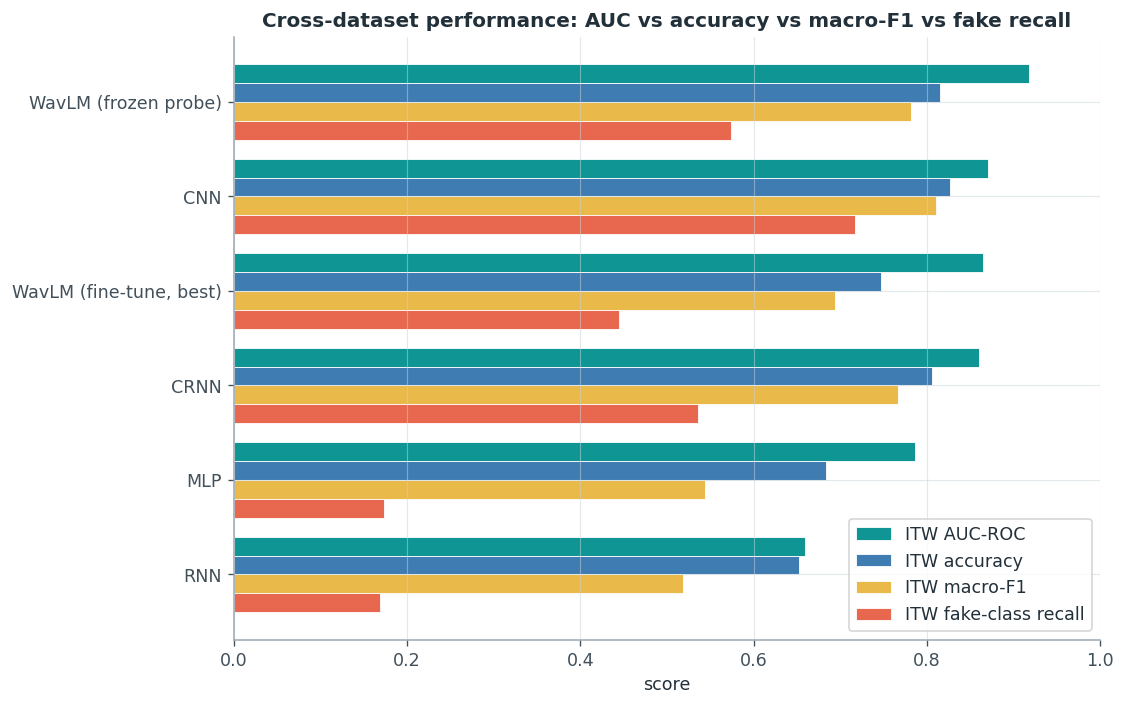

In [17]:
m = master.set_index("model")
order = m.sort_values("ITW_AUC").index
x = np.arange(len(order)); h = 0.2
plt.figure(figsize=(9.5,6))
plt.barh(x+1.5*h, m.loc[order,"ITW_AUC"],  h, label="ITW AUC-ROC",           color=PAL["teal"],  edgecolor="white", linewidth=0.5)
plt.barh(x+0.5*h, m.loc[order,"ITW_acc"],  h, label="ITW accuracy",          color=PAL["blue"],  edgecolor="white", linewidth=0.5)
plt.barh(x-0.5*h, m.loc[order,"macro_F1"], h, label="ITW macro-F1",          color=PAL["amber"], edgecolor="white", linewidth=0.5)
plt.barh(x-1.5*h, m.loc[order,"fake_R"],   h, label="ITW fake-class recall", color=PAL["coral"], edgecolor="white", linewidth=0.5)
plt.yticks(x, order); plt.xlim(0,1.0); plt.xlabel("score")
plt.title("Cross-dataset performance: AUC vs accuracy vs macro-F1 vs fake recall")
plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

**Reading the comparison.**

- **By AUC**, the ranking is clean: **WavLM probe (0.92) > CNN (0.87) ~ CRNN (0.86) > WavLM fine-tune (0.85) > MLP (0.79) > RNN (0.66)**.
- **By macro-F1** (the balanced average across both classes), the real-biased models are penalised hard: the MLP and RNN fall well behind because their fake-class F1 is ~0.27-0.29, while the CNN, CRNN and frozen WavLM probe stay strong - macro-F1 exposes the imbalance that plain accuracy hides.
- **By fake recall**, the picture sharpens and partly *reorders*. The **CNN catches ~72% of fakes** - the best at its operating point - whereas the **MLP and RNN catch only ~17%**: they ride the 63% "real" majority to a passable accuracy while being nearly useless as detectors. Even the high-AUC WavLM fine-tune flags only ~39% of fakes at its threshold, a direct symptom of the domain shift.
- The central lesson of the imbalance: **a respectable accuracy or AUC does not imply a usable detector.** The CNN and the frozen WavLM probe are the only models both well-ranked *and* operationally effective at catching fakes.

### 8.1 Generalisation gap (FoR -> ITW)
How much does each model lose moving from in-domain validation to the cross-dataset test? A large gap signals overfitting to FoR-specific artefacts.

,model,FoR_val_acc,ITW_acc,drop
0,CNN,0.7359,0.8266,-0.0907
1,MLP,0.6770,0.6832,-0.0062
2,CRNN,0.8343,0.8054,0.0289
3,WavLM probe,0.9204,0.8147,0.1057
4,WavLM fine-tune,0.9543,0.7474,0.2068
5,RNN,0.9530,0.6524,0.3005


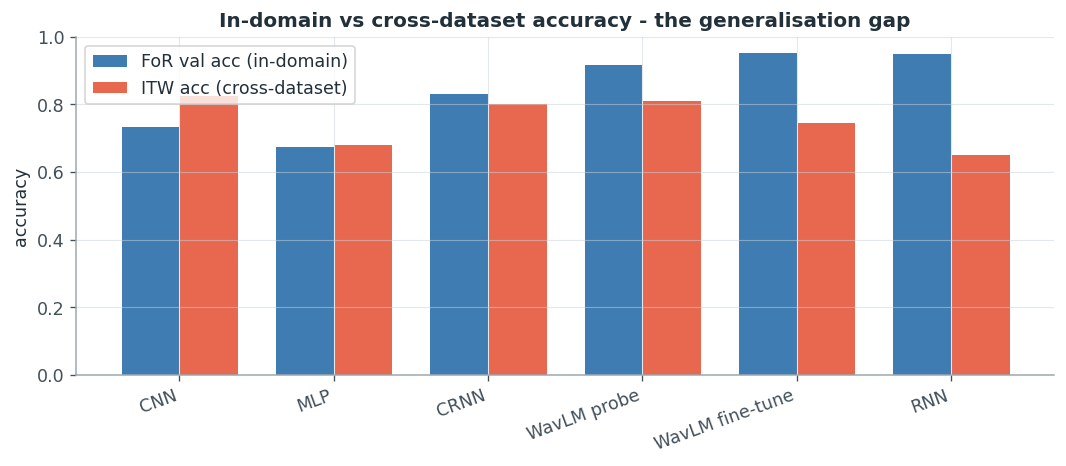

In [18]:
gap_rows = []
for fam, sub in FAM.items():
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    for_acc = max(hist["val_acc"])
    gap_rows.append({"model": fam, "FoR_val_acc": for_acc, "ITW_acc": top["test_acc"], "drop": for_acc - top["test_acc"]})
gap_rows.append({"model": "WavLM probe", "FoR_val_acc": probe["for_val"]["acc"], "ITW_acc": probe["itw_test"]["acc"], "drop": probe["for_val"]["acc"] - probe["itw_test"]["acc"]})
gap_rows.append({"model": "WavLM fine-tune", "FoR_val_acc": best_ft["for_val"]["acc"], "ITW_acc": best_ft["itw_test"]["acc"], "drop": best_ft["for_val"]["acc"] - best_ft["itw_test"]["acc"]})
gap = pd.DataFrame(gap_rows).sort_values("drop").reset_index(drop=True)
display(gap)

g = gap.set_index("model"); x = np.arange(len(g)); h = 0.38
plt.figure(figsize=(9,4))
plt.bar(x-h/2, g["FoR_val_acc"], h, label="FoR val acc (in-domain)", color=PAL["blue"],  edgecolor="white", linewidth=0.6)
plt.bar(x+h/2, g["ITW_acc"], h, label="ITW acc (cross-dataset)", color=PAL["coral"], edgecolor="white", linewidth=0.6)
plt.xticks(x, g.index, rotation=20, ha="right"); plt.ylim(0,1.0); plt.ylabel("accuracy")
plt.title("In-domain vs cross-dataset accuracy - the generalisation gap")
plt.legend(); plt.tight_layout(); plt.show()

**Interpretation.** The **fine-tuned WavLM shows the widest gap** - near-perfect FoR accuracy crashing on ITW - confirming source-domain overfitting. The **frozen probe transfers best** (small gap, highest ITW). Among from-scratch models the CNN/CRNN gap is moderate, while the MLP/RNN gap is partly masked because they are weak in both domains.

### 8.2 Training dynamics
Validation-accuracy curves for the best run of each from-scratch family.

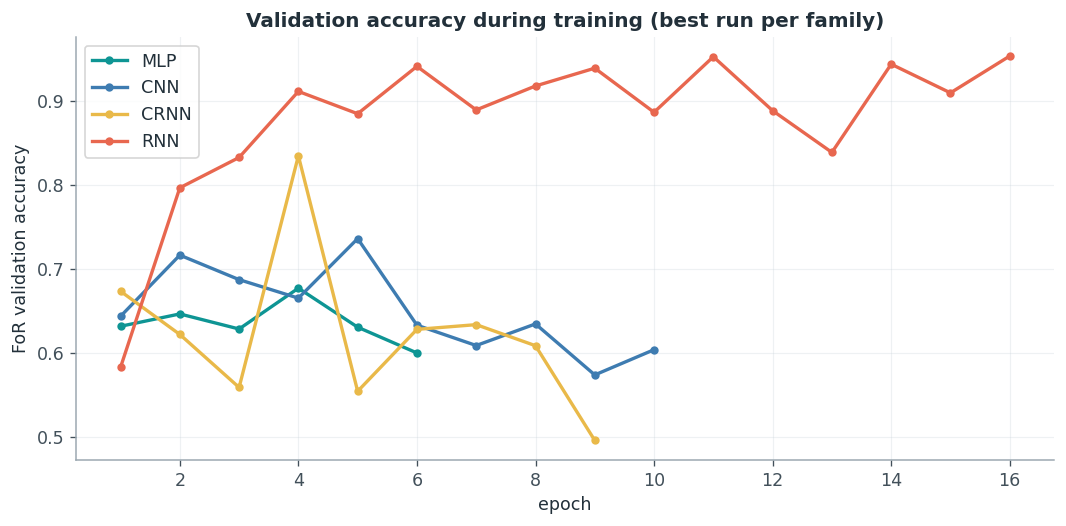

In [19]:
cyc = [PAL["teal"], PAL["blue"], PAL["amber"], PAL["coral"]]
plt.figure(figsize=(9,4.5))
for (fam, sub), col in zip(FAM.items(), cyc):
    top = summ[fam].iloc[0]
    hist = json.load(open(RESULTS / sub / "experiments" / top["tag"] / "checkpoints" / ("history_" + top["tag"] + ".json")))
    plt.plot(range(1, len(hist["val_acc"])+1), hist["val_acc"], marker="o", ms=4, lw=2, color=col, label=fam)
plt.xlabel("epoch"); plt.ylabel("FoR validation accuracy")
plt.title("Validation accuracy during training (best run per family)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 9. Noise robustness & augmentation
Robustness is currently addressed on the **training side**: the WavLM fine-tune uses an online waveform-augmentation pipeline - **MUSAN additive noise (0-15 dB SNR), simulated-RIR reverberation, and codec compression** - applied to the **training split only** to prevent leakage.

A dedicated **evaluation-side** study is the planned extension: corrupt the **test** set at fixed SNRs (e.g. 10 dB, 0 dB) and reverberation, then re-score every checkpoint to produce an **AUC-vs-SNR degradation curve** per architecture. It is inference-only - WavLM scores corrupted waveforms directly; feature models corrupt the waveform, re-extract with the saved clean scaler, and score - reusing the existing augmentation pipeline run deterministically over a **held-out** noise/RIR partition disjoint from training.

## 10. Conclusions

- **Representation learning is the dominant factor in cross-dataset AUC:** hand-crafted+MLP (0.79) -> learned CNN/CRNN (0.86-0.87) -> self-supervised WavLM (0.92).
- **Accuracy/AUC must be read together with fake-class recall.** On imbalanced ITW the MLP and RNN catch only ~17% of fakes despite passable accuracy; the CNN (~72%) and frozen WavLM probe are the only both-well-ranked-and-operationally-effective detectors.
- **Convolution carries the recurrent path** - pure BiLSTM 0.66 vs CRNN 0.86.
- **Capacity and regularisation must be tuned, not maximised** - middle depth/width and moderate weight decay generalise best.
- **For a pretrained backbone under domain shift, freezing beats fine-tuning** - the frozen probe is the best cross-dataset model; fine-tuning saturates FoR (AUC ~0.99) and loses ITW transfer.
- **The spoofing cue is a mid-network acoustic feature** - WavLM layer 4 dominates the probe.

**Future work.** Evaluation-side noise-robustness curves (Section 9); EER reporting alongside AUC; multi-seed runs for error bars; threshold calibration to lift fake recall on the high-AUC models.


## 11. Methodology Analysis

### 11.1 Experimental design

The project is a **controlled comparative study** structured as an inductive-bias ladder. The four families are designed so that each step increases the fraction of the audio processing pipeline that is learned from data rather than fixed by the engineer:

| Step | Family | What the engineer pre-computes | What the model learns |
|------|--------|-------------------------------|----------------------|
| 0 | **MLP** | Full feature set (MFCC, chroma, spectral contrast, ZCR) | Classifier weights only |
| 1 | **CNN** | Resampling + log mel transform | Local 2-D spectro-temporal filters + classifier |
| 2 | **RNN / CRNN** | Same log mel as CNN | Temporal dynamics (BiLSTM); ± CNN front-end |
| 3 | **WavLM** | Resampling to 16 kHz + waveform normalisation | Everything — or only the weighted combination of frozen pre-trained layers (probe) |

The **research contribution is the comparison**, not the use of any individual model. By fixing the evaluation protocol (same train/val split, same cross-dataset test, same metrics) the only variable between families is what the model must learn, making the AUC trajectory interpretable as a function of representation depth.

### 11.2 Feature extraction

**MLP — 390-dimensional feature vector.** Extracted with Librosa at 16 kHz mono: 20 Mel-Frequency Cepstral Coefficients (frames of 256 samples, hop 128), 12-bin chroma, 7-band spectral contrast, and zero-crossing rate. Each feature is averaged across frames to produce a fixed-length per-clip vector. A `StandardScaler` is fit **exclusively on the training split** and reused unchanged at validation and test time to prevent any leakage.

**CNN / RNN / CRNN — 128 × T log mel-spectrogram.** Computed with torchaudio: 128 mel bins, 256-sample FFT window, 128-sample hop, at 16 kHz. Clips are center-cropped or zero-padded to a fixed duration so all spectrograms share the same T dimension. The CNN treats this as a single-channel 2-D image; the RNN/CRNN treat it as a T-step sequence of 128-dimensional frame vectors.

**WavLM — raw waveform.** The HuggingFace feature extractor normalises each waveform to zero mean and unit variance and passes it to `microsoft/wavlm-base-plus` without any hand-crafted feature extraction.

### 11.3 Training protocol

All from-scratch models share the same training loop:
- **Loss:** Binary cross-entropy with sigmoid output; inference threshold fixed at 0.5.
- **Optimiser:** Adam; **LR scheduler:** `ReduceLROnPlateau` (factor 0.5, patience 5 on validation loss).
- **Early stopping:** patience 10 epochs on validation loss; the best-epoch checkpoint is used at test time.
- **Batch size:** 64; **max epochs:** 100; **seed:** 42 (fixed globally for reproducibility).
- **Augmentation:** none for families 1–3.

WavLM fine-tuning uses **AdamW**, **bfloat16 autocast**, and **gradient clipping** (max norm 1.0). Online augmentation (MUSAN additive noise 0–15 dB SNR, simulated RIR reverberation, codec compression) is applied to the **training split only**. The frozen probe trains only the softmax-weighted layer aggregation and a linear head (~5K parameters).

### 11.4 Ablation design

Each from-scratch family receives **10 configurations** from a one-axis-at-a-time grid: one hyperparameter is varied while all others are held at a shared baseline (the modal value for each axis across all runs). This controlled design means each performance difference in Sections 4–6 is attributable to a single design choice, making the sensitivity curves directly interpretable.

In [20]:
# ─── Architecture pipeline summary table ──────────────────────────────
arch_rows = [
    ("MLP",
     "390-d feature vector\n(MFCC-20, chroma, spectral contrast, ZCR)",
     "Linear → BN → ReLU → Dropout × N",
     "~90K",
     "Hand-crafted features; classifier only"),
    ("CNN",
     "128×T log mel-spectrogram",
     "Conv2d(3×3) → AvgPool → Dropout × depth;\nAdaptiveAvgPool2d → Linear(256→1)",
     "~200K",
     "Learned 2-D spectro-temporal filters"),
    ("CRNN",
     "128×T log mel-spectrogram",
     "CNN blocks → flatten freq dim → BiLSTM layers;\nlast LSTM state → Linear(256→1)",
     "~600K",
     "2-D filters + explicit temporal dynamics"),
    ("RNN",
     "128×T log mel-spectrogram",
     "BiLSTM layers (hidden halves each layer);\nlast state → Linear(256→1)",
     "~250K",
     "Temporal dynamics only — no 2-D filters"),
    ("WavLM probe",
     "Raw waveform (16 kHz)",
     "Frozen backbone (12 transformer blocks + CNN stem);\nsoftmax-weighted layer sum → Linear(hidden→2)",
     "~5K trainable",
     "Self-supervised; probes mid-layer cues"),
    ("WavLM fine-tune",
     "Raw waveform (16 kHz)",
     "Full backbone (unfrozen) + linear head;\nAdamW, low LR, bfloat16 autocast",
     "~94M",
     "Self-supervised; domain-specific fitting"),
]
cols_arch = ["Input", "Core processing", "Params", "Key inductive bias"]
df_arch = pd.DataFrame(arch_rows, columns=["Model"] + cols_arch).set_index("Model")
pd.set_option("display.max_colwidth", 80)
print("Architecture pipeline overview\n")
display(df_arch)

# ─── Ablation grid: hyperparameters varied per family ─────────────────
print("\nAblation grid — one axis at a time, 10 configurations per family\n")
grid_rows = []
for fam in ["MLP", "CNN", "CRNN", "RNN"]:
    d = family_table(fam, FAM[fam])
    baseline = {c: d[c].mode().iloc[0] for c in CONFIG_COLS[fam]}
    for c in CONFIG_COLS[fam]:
        vals = sorted(d[c].unique(), key=_sortkey)
        grid_rows.append({
            "Family": fam,
            "Hyperparameter": _ABBR.get(c, c),
            "Full name": c,
            "Baseline": _fmt(baseline[c]),
            "Values tested": " | ".join(_fmt(v) for v in vals),
            "# levels": d[c].nunique(),
        })
df_grid = pd.DataFrame(grid_rows)
display(df_grid.set_index(["Family", "Hyperparameter"]))

Architecture pipeline overview



,Input,Core processing,Params,Key inductive bias
Model,,,,
MLP,"390-d feature vector\n(MFCC-20, chroma, spectral contrast, ZCR)",Linear → BN → ReLU → Dropout × N,~90K,Hand-crafted features; classifier only
CNN,128×T log mel-spectrogram,Conv2d(3×3) → AvgPool → Dropout × depth;\nAdaptiveAvgPool2d → Linear(256→1),~200K,Learned 2-D spectro-temporal filters
CRNN,128×T log mel-spectrogram,CNN blocks → flatten freq dim → BiLSTM layers;\nlast LSTM state → Linear(256→1),~600K,2-D filters + explicit temporal dynamics
RNN,128×T log mel-spectrogram,BiLSTM layers (hidden halves each layer);\nlast state → Linear(256→1),~250K,Temporal dynamics only — no 2-D filters
WavLM probe,Raw waveform (16 kHz),Frozen backbone (12 transformer blocks + CNN stem);\nsoftmax-weighted layer ...,~5K trainable,Self-supervised; probes mid-layer cues
WavLM fine-tune,Raw waveform (16 kHz),"Full backbone (unfrozen) + linear head;\nAdamW, low LR, bfloat16 autocast",~94M,Self-supervised; domain-specific fitting



Ablation grid — one axis at a time, 10 configurations per family



Full name        Baseline  \
Family Hyperparameter                                   
MLP    h                 hidden_sizes  [256, 128, 64]   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
CNN    depth                    depth               3   
       ch               base_channels              32   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
CRNN   cd                   cnn_depth               3   
       ch               base_channels              32   
       rl              num_rnn_layers               2   
       rh                  rnn_hidden             128   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   
RNN    L                   num_layers               2   
       h                  hidden_size             128   
       lr                          lr            5e-4   
       do                     dropout             0.5   
       wd                weight_decay            1e-4   

                                                                                         Values tested  \
Family Hyperparameter                                                                                    
MLP    h               [128] | [256, 128] | [256, 128, 64] | [512, 256, 128] | [256, 128, 64, 32] |...   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                                  1e-4 | 1e-3   
CNN    depth                                                                                 2 | 3 | 4   
       ch                                                                                 16 | 32 | 64   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                           1e-5 | 1e-4 | 1e-3   
CRNN   cd                                                                                    2 | 3 | 4   
       ch                                                                                 16 | 32 | 64   
       rl                                                                                    1 | 2 | 3   
       rh                                                                                          128   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                                         1e-4   
RNN    L                                                                                     1 | 2 | 3   
       h                                                                                64 | 128 | 256   
       lr                                                                           1e-4 | 5e-4 | 1e-3   
       do                                                                                    0.3 | 0.5   
       wd                                                                           1e-5 | 1e-4 | 1e-3   

                       # levels  
Family Hyperparameter            
MLP    h                      6  
       lr                     3  
       do                     2  
       wd                     2  
CNN    depth                  3  
       ch                     3  
     

## 12. Experiment Analysis

The within-family ablations converge on three cross-cutting findings.

### 12.1 Performance ceilings are set by representation, not capacity

The AUC range *within* each family — the gap between the best and worst configuration — is far smaller than the gap *between* families. The MLP tops out at ~0.79 regardless of hidden-layer width or depth; the pure RNN tops out at ~0.66 regardless of recurrent capacity. Increasing model size within the MLP actually hurts (the widest nets overfit FoR-specific correlations). This means the binding constraint on cross-dataset generalisation is the **input representation**, not the classifier. No amount of capacity added to an MLP over hand-crafted features will close the gap to a CNN over spectrograms.

### 12.2 Learning rate is the single most impactful hyperparameter

Across all four families, the learning rate explains more within-family AUC variance than depth, channel count, or regularisation. This is partly a property of the loss landscape (well-conditioned enough that a larger step finds a better basin within the epoch budget) and partly a consequence of the modest dataset size and training schedule. For the recurrent path, this observation has a sharper edge: the CRNN collapses from AUC 0.86 to 0.56 when `lr` moves from `5e-4` to `1e-3`, while the pure CNN *benefits* from that higher rate. The BiLSTM's recurrent gradient magnitudes are more sensitive to step size than convolutional filters.

### 12.3 Regularisation must be calibrated, not maximised

Dropout 0.5 consistently outperforms 0.3 across all families. Weight decay, however, shows a **sharp bifurcation**: `1e-4` helps, `1e-3` is catastrophic for mel-based models (driving CNN and CRNN AUC toward chance). The MLP is more tolerant of strong L2 because the feature space is low-dimensional and fixed — the regularisation falls on the classifier weights, which is benign. For CNNs and CRNNs, heavy weight decay prevents convolutional filters from sharpening, effectively undoing the representation learning that makes those models strong.

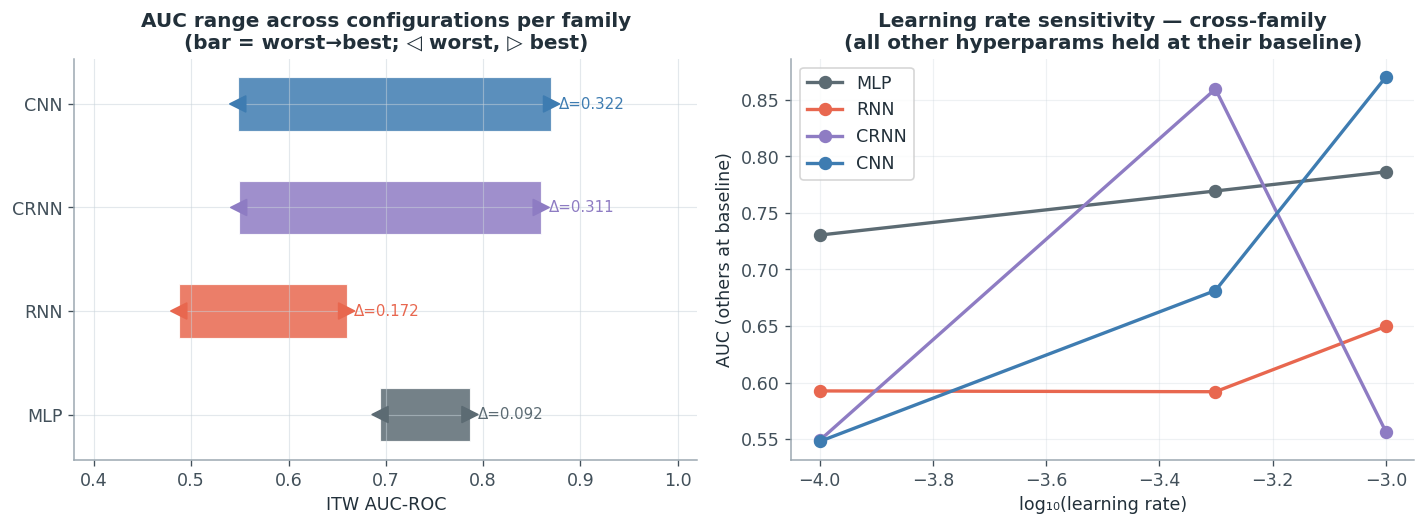

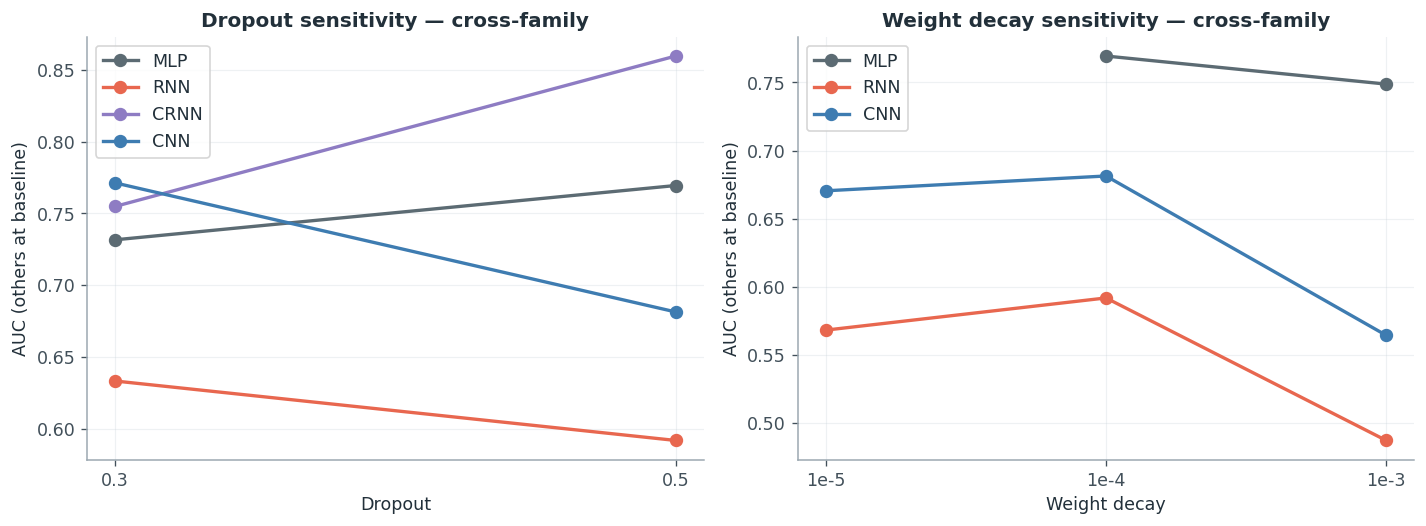

In [21]:
# Cache all family tables once to avoid repeated disk reads
_fam_tables = {fam: family_table(fam, FAM[fam]) for fam in ["MLP", "CNN", "CRNN", "RNN"]}
fam_order = ["MLP", "RNN", "CRNN", "CNN"]   # ascending complexity / ceiling
pal_fam   = [PAL["slate"], PAL["coral"], PAL["violet"], PAL["blue"]]

# ─── AUC range per family: sensitivity to configuration ────────────────
range_data = {fam: {"best": d["AUC"].max(), "worst": d["AUC"].min(),
                    "spread": d["AUC"].max() - d["AUC"].min()}
              for fam, d in _fam_tables.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
x = np.arange(len(fam_order))
bests   = [range_data[f]["best"]   for f in fam_order]
worsts  = [range_data[f]["worst"]  for f in fam_order]
spreads = [range_data[f]["spread"] for f in fam_order]
ax.barh(x, spreads, left=worsts, height=0.52, color=pal_fam,
        edgecolor="white", lw=0.7, alpha=0.85)
ax.scatter(bests,  x, zorder=5, color=pal_fam, s=90, marker=">")
ax.scatter(worsts, x, zorder=5, color=pal_fam, s=90, marker="<")
ax.set_yticks(x); ax.set_yticklabels(fam_order)
ax.set_xlabel("ITW AUC-ROC"); ax.set_xlim(0.38, 1.02)
ax.set_title("AUC range across configurations per family\n(bar = worst→best; ◁ worst, ▷ best)")
for i, (b, s, col) in enumerate(zip(bests, spreads, pal_fam)):
    ax.text(b + 0.008, i, f"Δ={s:.3f}", va="center", fontsize=9, color=col)

# ─── LR sensitivity: cross-family on the same axes ──────────────────
ax = axes[1]
for fam, col in zip(fam_order, pal_fam):
    d = _fam_tables[fam]
    others = [c for c in CONFIG_COLS[fam] if c != "lr"]
    base = {c: d[c].mode().iloc[0] for c in others}
    mask = (d[others] == pd.Series(base)).all(axis=1) if others else pd.Series([True]*len(d))
    sd = d[mask].copy()
    if sd["lr"].nunique() < 2:
        continue
    sd = sd.assign(_sk=sd["lr"].map(_sortkey)).sort_values("_sk")
    xvals = np.log10(sd["lr"].astype(float))
    ax.plot(xvals, sd["AUC"], marker="o", ms=7, lw=2, color=col, label=fam)

ax.set_xlabel("log₁₀(learning rate)")
ax.set_ylabel("AUC (others at baseline)")
ax.set_title("Learning rate sensitivity — cross-family\n(all other hyperparams held at their baseline)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ─── Regularisation: dropout and weight_decay ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (param, label) in zip(axes, [("dropout", "Dropout"),
                                      ("weight_decay", "Weight decay")]):
    # global x-axis: union of all values tested across families
    all_vals = sorted(
        {v for fam in fam_order if param in CONFIG_COLS[fam]
           for v in _fam_tables[fam][param].unique()},
        key=_sortkey
    )
    val_to_x = {v: i for i, v in enumerate(all_vals)}

    for fam, col in zip(fam_order, pal_fam):
        if param not in CONFIG_COLS[fam]:
            continue
        d = _fam_tables[fam]
        others = [c for c in CONFIG_COLS[fam] if c != param]
        base = {c: d[c].mode().iloc[0] for c in others}
        mask = (d[others] == pd.Series(base)).all(axis=1) if others else pd.Series([True]*len(d))
        sd = d[mask].copy()
        if sd[param].nunique() < 2:
            continue
        sd = sd.assign(_sk=sd[param].map(_sortkey)).sort_values("_sk")
        xpts = [val_to_x.get(v, np.nan) for v in sd[param]]
        ax.plot(xpts, sd["AUC"], marker="o", ms=7, lw=2, color=col, label=fam)

    ax.set_xticks(range(len(all_vals)))
    ax.set_xticklabels([_fmt(v) for v in all_vals])
    ax.set_xlabel(label); ax.set_ylabel("AUC (others at baseline)")
    ax.set_title(f"{label} sensitivity — cross-family")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 13. Results Analysis

### 13.1 The AUC vs fake-recall tension

AUC measures **ranking quality** — how often the model scores a fake above a real at any threshold — while fake-class recall measures **operational effectiveness** at a fixed threshold (0.5 by default). These are related but distinct, and their divergence exposes the cost of class imbalance and domain shift.

On ITW (~63% real), a model trained with cross-entropy is implicitly biased toward the majority class. Its decision boundary drifts toward "predict real", lifting real-class recall at the cost of fake-class recall. AUC is threshold-free so it is less sensitive to this shift; a model can rank well while still missing many fakes at any reasonable operating point.

The consequence is visible in the data: the **WavLM fine-tune reaches ITW AUC 0.865 yet catches only 44.5% of fakes**. The **CNN, with a similar AUC of 0.870, catches 71.7%**. The operational question — *which model do you actually deploy?* — is answered by fake-recall, not by AUC alone.

### 13.2 Error decomposition

Each model's errors decompose into two types:
- **False negatives on fakes** (missed detections, `1 − fake_recall`): the primary failure mode. MLP and RNN miss ~83% of fakes, rendering them operationally useless despite passable accuracy.
- **False positives on real** (false alarms, `1 − real_recall`): secondary. All models classify real speech reasonably well; the discriminative challenge is entirely on the fake side.

The CNN and frozen WavLM probe are the only models where **both error types fall below 30%**. Every other model is either weak on ranking (RNN) or effective at ranking but poorly calibrated for detection (WavLM fine-tune, CRNN at its threshold).

### 13.3 Pareto efficiency

On the joint (AUC, fake-recall) space, only two models are **Pareto-optimal**: the **frozen WavLM probe** (best AUC, middle recall) and the **CNN** (lower AUC, highest recall). Every other model is dominated by at least one of these two. The key trade-off is between the probe's superior ranking quality and the CNN's superior detection rate at the default threshold. A threshold calibration step on the WavLM probe (lowering the decision boundary) could potentially make it dominate the CNN on both axes simultaneously.

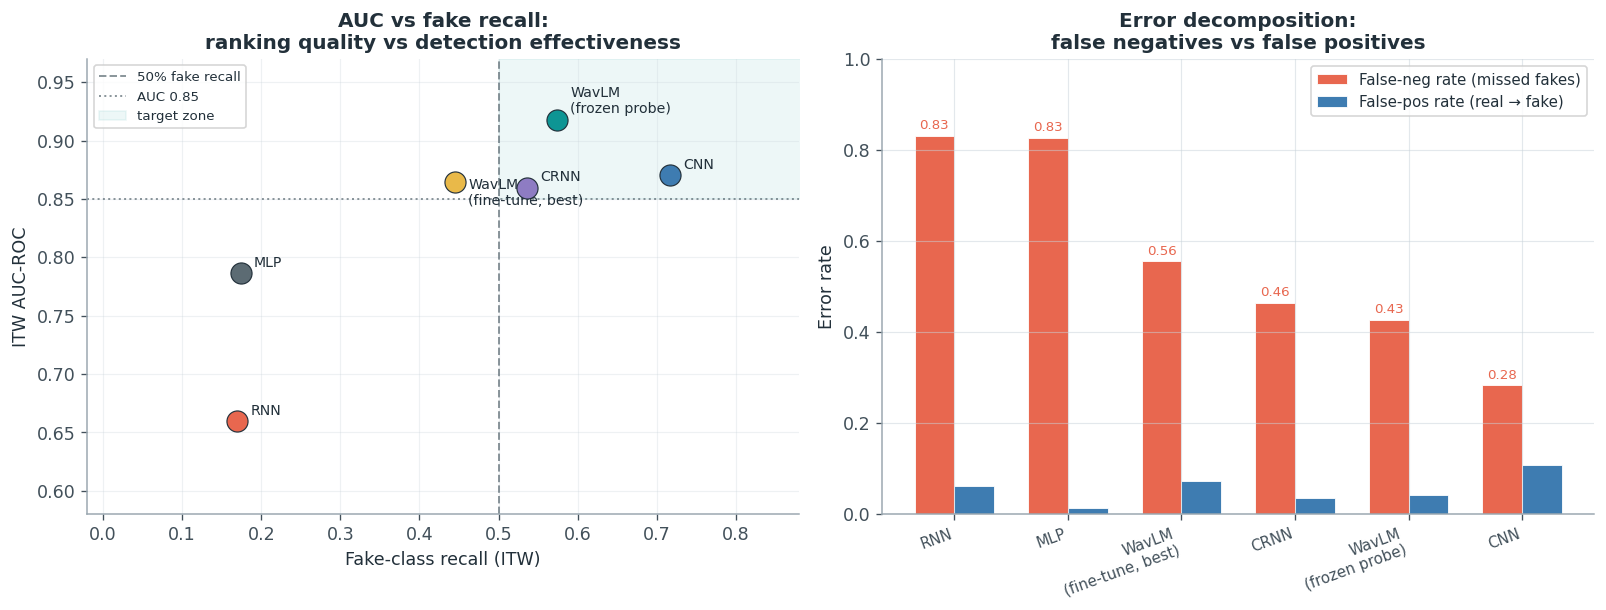

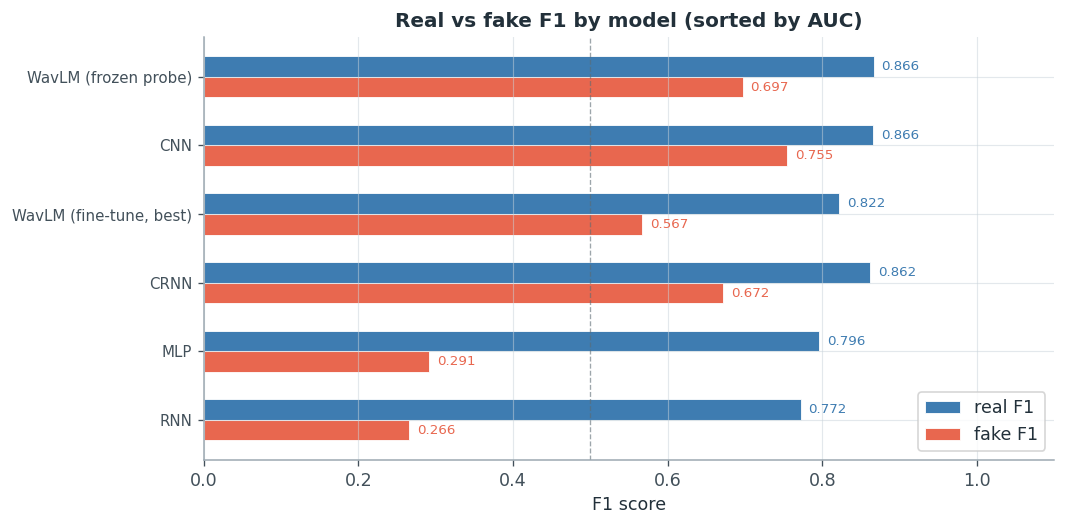

Pareto-optimal models: ['WavLM (frozen probe)', 'CNN']


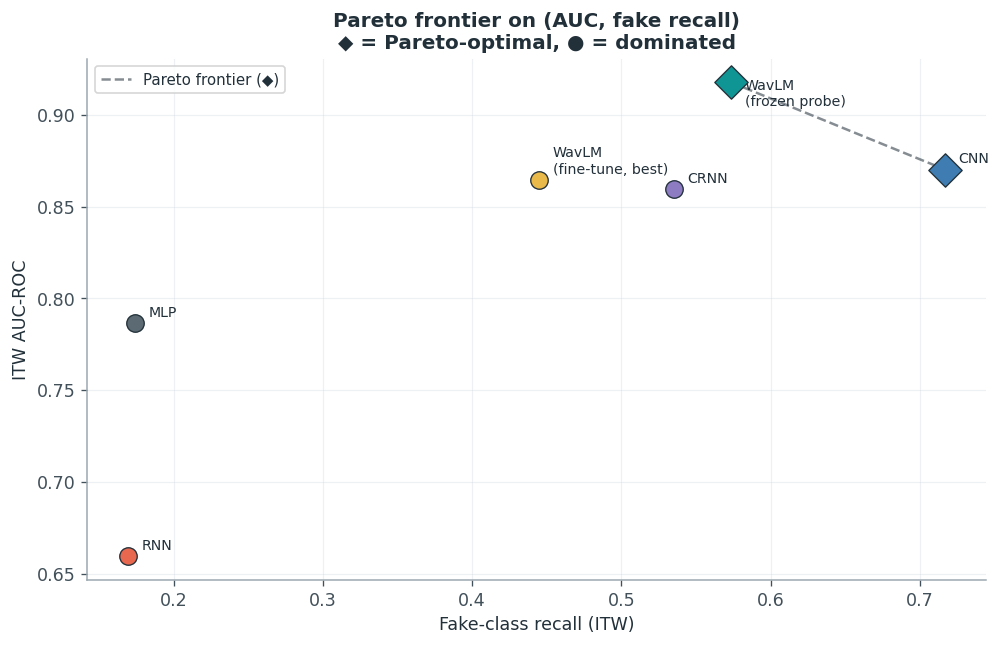

In [22]:
# ─── 1. AUC vs fake-recall scatter ─────────────────────────────────────
pal_map = {"MLP": PAL["slate"], "CNN": PAL["blue"], "CRNN": PAL["violet"],
           "RNN": PAL["coral"], "WavLM (frozen probe)": PAL["teal"],
           "WavLM (fine-tune, best)": PAL["amber"]}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

ax = axes[0]
for _, row in master.iterrows():
    name = row["model"]
    col = pal_map.get(name, PAL["ink"])
    ax.scatter(row["fake_R"], row["ITW_AUC"], s=160, color=col, zorder=5,
               edgecolors=PAL["ink"], linewidths=0.7)
    xytext = (8, 4)
    if name == "WavLM (fine-tune, best)": xytext = (8, -14)
    ax.annotate(name.replace("WavLM ", "WavLM\n"), (row["fake_R"], row["ITW_AUC"]),
                textcoords="offset points", xytext=xytext, fontsize=8.5, color=PAL["ink"])

ax.axvline(0.5, color=PAL["slate"], ls="--", lw=1.2, alpha=0.7, label="50% fake recall")
ax.axhline(0.85, color=PAL["slate"], ls=":", lw=1.2, alpha=0.7, label="AUC 0.85")
ax.fill_between([0.5, 0.9], [0.85, 0.85], [0.97, 0.97], alpha=0.07,
                color=PAL["teal"], label="target zone")
ax.set_xlabel("Fake-class recall (ITW)")
ax.set_ylabel("ITW AUC-ROC")
ax.set_title("AUC vs fake recall:\nranking quality vs detection effectiveness")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim(-0.02, 0.88); ax.set_ylim(0.58, 0.97)

# ─── 2. False negative vs false positive rates ─────────────────────────
ax = axes[1]
order_fn = master.sort_values("fake_R")
x = np.arange(len(order_fn)); h = 0.35
fn = 1 - order_fn["fake_R"].values
fp = 1 - order_fn["real_R"].values
bars1 = ax.bar(x - h/2, fn, h, label="False-neg rate (missed fakes)",
               color=PAL["coral"], edgecolor="white", lw=0.5)
bars2 = ax.bar(x + h/2, fp, h, label="False-pos rate (real → fake)",
               color=PAL["blue"], edgecolor="white", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(order_fn["model"].str.replace("WavLM ", "WavLM\n"),
                   rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Error rate"); ax.set_ylim(0, 1.0)
ax.set_title("Error decomposition:\nfalse negatives vs false positives")
ax.legend(fontsize=9)
for bar, v in zip(bars1, fn):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015,
            f"{v:.2f}", ha="center", fontsize=8, color=PAL["coral"])
plt.tight_layout(); plt.show()

# ─── 3. Real vs fake F1 decomposition ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))
order_m = master.sort_values("ITW_AUC", ascending=True)
y = np.arange(len(order_m)); h = 0.3
ax.barh(y + h/2, order_m["real_F1"], h, color=PAL["blue"],  label="real F1",
        edgecolor="white", lw=0.5)
ax.barh(y - h/2, order_m["fake_F1"], h, color=PAL["coral"], label="fake F1",
        edgecolor="white", lw=0.5)
ax.set_yticks(y); ax.set_yticklabels(order_m["model"], fontsize=9)
ax.set_xlim(0, 1.1); ax.set_xlabel("F1 score")
ax.axvline(0.5, color=PAL["slate"], ls="--", lw=0.8, alpha=0.6)
ax.set_title("Real vs fake F1 by model (sorted by AUC)")
ax.legend(loc="lower right")
for i, row in enumerate(order_m.itertuples()):
    ax.text(row.real_F1 + 0.01, i + h/2, f"{row.real_F1:.3f}",
            va="center", fontsize=8, color=PAL["blue"])
    ax.text(row.fake_F1 + 0.01, i - h/2, f"{row.fake_F1:.3f}",
            va="center", fontsize=8, color=PAL["coral"])
plt.tight_layout(); plt.show()

# ─── 4. Pareto frontier: AUC + fake_recall ─────────────────────────────
fig, ax = plt.subplots(figsize=(8.5, 5.5))
pts = master[["model", "ITW_AUC", "fake_R"]].copy()
pareto_mask = []
for i, row in pts.iterrows():
    dominated = any(
        (other["model"] != row["model"])
        and (other["ITW_AUC"] >= row["ITW_AUC"])
        and (other["fake_R"] >= row["fake_R"])
        and (other["ITW_AUC"] > row["ITW_AUC"] or other["fake_R"] > row["fake_R"])
        for _, other in pts.iterrows()
    )
    pareto_mask.append(not dominated)

for (_, row), is_pareto in zip(pts.iterrows(), pareto_mask):
    name = row["model"]
    col = pal_map.get(name, PAL["ink"])
    marker = "D" if is_pareto else "o"
    size = 200 if is_pareto else 110
    ax.scatter(row["fake_R"], row["ITW_AUC"], s=size, color=col, marker=marker,
               zorder=5, edgecolors=PAL["ink"], linewidths=0.8)
    xytext = (8, 4)
    if row["ITW_AUC"] > 0.88 and row["fake_R"] < 0.65:
        xytext = (8, -14)
    ax.annotate(name.replace("WavLM ", "WavLM\n"), (row["fake_R"], row["ITW_AUC"]),
                textcoords="offset points", xytext=xytext, fontsize=8.5, color=PAL["ink"])

pareto_pts = pts[pareto_mask].sort_values("fake_R")
ax.plot(pareto_pts["fake_R"], pareto_pts["ITW_AUC"],
        color=PAL["ink"], lw=1.5, ls="--", alpha=0.55, label="Pareto frontier (◆)")
ax.set_xlabel("Fake-class recall (ITW)")
ax.set_ylabel("ITW AUC-ROC")
ax.set_title("Pareto frontier on (AUC, fake recall)\n◆ = Pareto-optimal, ● = dominated")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
print("Pareto-optimal models:", pts[pareto_mask]["model"].tolist())
plt.tight_layout(); plt.show()